# GPU Eigen Centrality — Full Metrics Analysis
**Methods:** `csr_scalar` · `cu_sparse` · `lanczos` · `our_code`  
**Datasets:** Amazon0601 · com-orkut.ungraph · germany_osm · roadNet-CA · soc-LiveJournal1 · soc-pokec-relationships

In [3]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
    'axes.labelsize': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.titlesize': 14,
    'figure.titleweight': 'bold',
})

METHOD_COLORS = {
    'csr_scalar': '#378ADD',
    'cu_sparse':  '#1D9E75',
    'lanczos':    '#EF9F27',
    'our_code':   '#D4537E',
}
METHOD_LABELS = {
    'csr_scalar': 'CSR Scalar',
    'cu_sparse':  'cuSPARSE',
    'lanczos':    'Lanczos',
    'our_code':   'Our Code',
}
DS_SHORT = {
    'Amazon0601':              'Amazon',
    'com-orkut.ungraph':       'Orkut',
    'germany_osm':             'Germany OSM',
    'roadNet-CA':              'RoadNet-CA',
    'soc-LiveJournal1':        'LiveJournal',
    'soc-pokec-relationships': 'Pokec',
}
print('Setup complete.')

Setup complete.


In [4]:
# ── Load & flatten data ──────────────────────────────────────────────────────
with open('../baseline/gpu_all_metrics.json') as f:
    raw = json.load(f)

rows = []
for ds, methods in raw.items():
    for method, vals in methods.items():
        row = dict(vals)
        row['dataset_short'] = DS_SHORT.get(ds, ds)
        row['method_key'] = method
        row['method_label'] = METHOD_LABELS.get(method, method)
        rows.append(row)

df = pd.DataFrame(rows)
DATASETS  = [DS_SHORT[d] for d in raw.keys()]
METHODS   = list(METHOD_COLORS.keys())
print(f'Loaded {len(df)} rows  |  datasets: {DATASETS}')
df[['dataset_short','method_label','execution_time_ms','mteps','iterations','converged',
    'final_residual','reconstruction_error_l2','bw_util_percent']].head(8)

Loaded 24 rows  |  datasets: ['Amazon', 'Orkut', 'Germany OSM', 'RoadNet-CA', 'LiveJournal', 'Pokec']


,dataset_short,method_label,execution_time_ms,mteps,iterations,converged,final_residual,reconstruction_error_l2,bw_util_percent
0,Amazon,CSR Scalar,324.887817,15041.548924,1000,False,3.821059e-06,0.000220,65.298871
1,Amazon,cuSPARSE,51.214272,28339.451255,297,True,9.372632e-07,0.000050,86.431818
2,Amazon,Lanczos,238.073471,20526.503764,1000,True,NaN,0.122972,NaN
3,Amazon,Our Code,47.608306,16320.760163,159,True,9.911925e-08,0.033050,NaN
4,Orkut,CSR Scalar,487.078339,15397.616189,32,True,9.702883e-07,0.001362,52.519819
5,Orkut,cuSPARSE,194.536636,38552.354213,32,True,9.928605e-07,0.000524,88.335171
6,Orkut,Lanczos,NaN,NaN,50,True,NaN,NaN,NaN
7,Orkut,Our Code,222.399461,15807.378643,15,True,9.300292e-08,0.491639,NaN


## 1 — Execution time comparison (grouped bar)

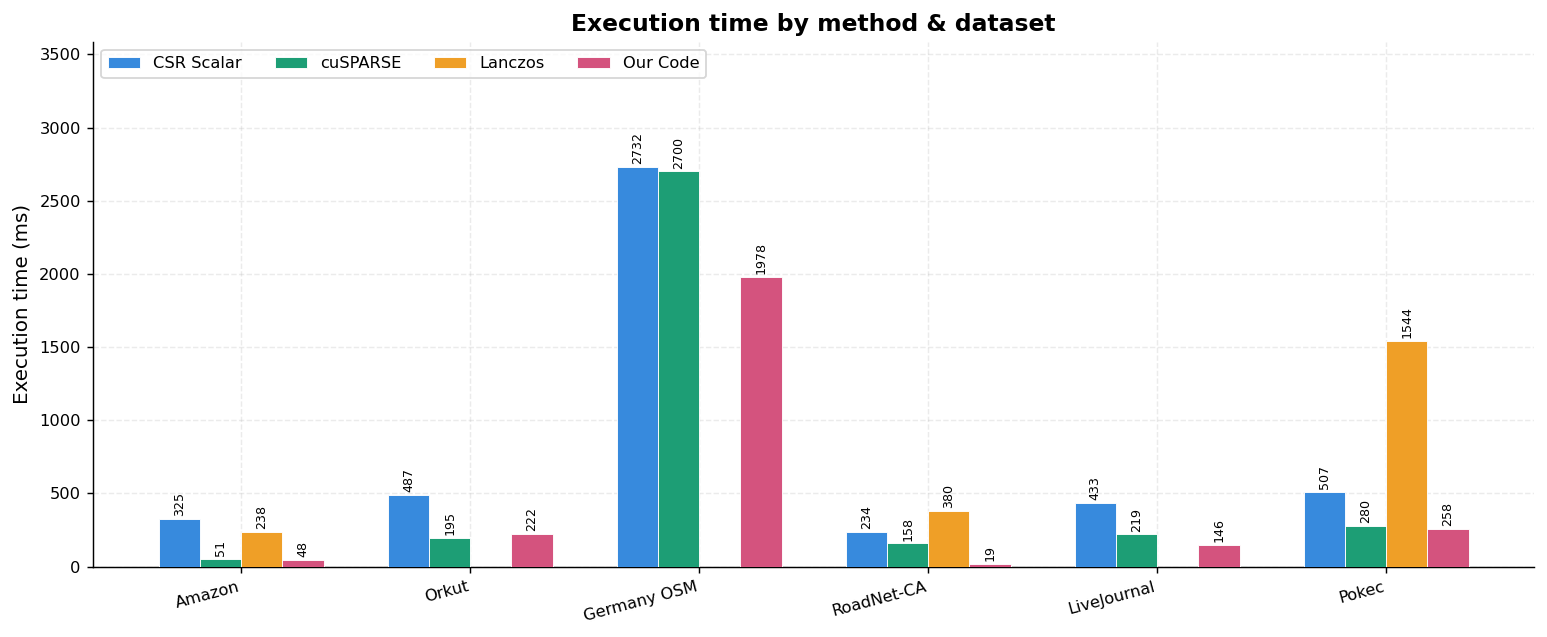

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(DATASETS))
w = 0.18
for i, m in enumerate(METHODS):
    vals = [df[(df.dataset_short == ds) & (df.method_key == m)]['execution_time_ms'].values
            for ds in DATASETS]
    vals = [v[0] if len(v) else np.nan for v in vals]
    bars = ax.bar(x + i*w - 1.5*w, vals, width=w,
                  color=METHOD_COLORS[m], label=METHOD_LABELS[m],
                  zorder=3, edgecolor='white', linewidth=0.5)
    for bar, v in zip(bars, vals):
        if not np.isnan(v) and v > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                    f'{v:.0f}', ha='center', va='bottom', fontsize=7, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(DATASETS, rotation=15, ha='right')
ax.set_ylabel('Execution time (ms)')
ax.set_title('Execution time by method & dataset')
ax.legend(loc='upper left', ncol=4)
ax.set_ylim(0, ax.get_ylim()[1] * 1.25)
plt.tight_layout()
plt.savefig('plot_01_exec_time_grouped_bar.png', bbox_inches='tight')
plt.show()

## 2 — Speedup relative to csr_scalar baseline

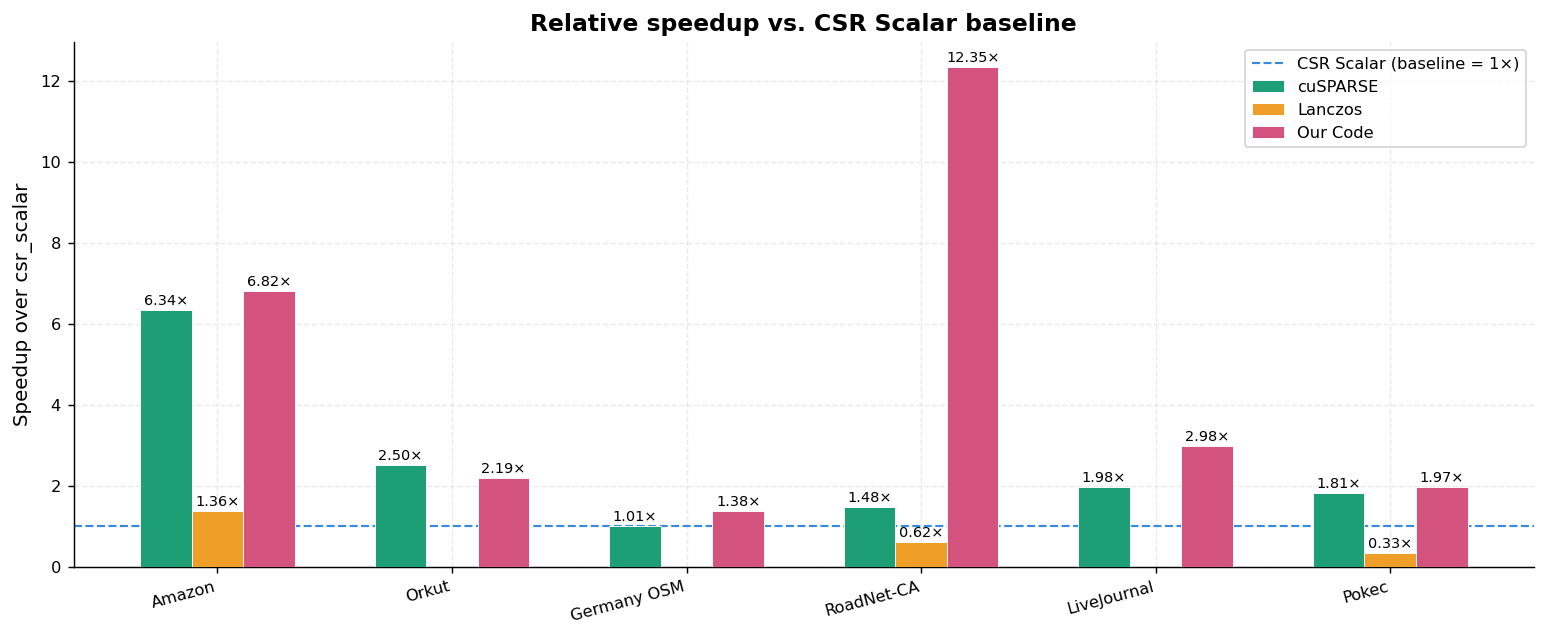

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(DATASETS))
w = 0.22
for i, m in enumerate([m for m in METHODS if m != 'csr_scalar']):
    speedups = []
    for ds in DATASETS:
        base = df[(df.dataset_short == ds) & (df.method_key == 'csr_scalar')]['execution_time_ms'].values
        comp = df[(df.dataset_short == ds) & (df.method_key == m)]['execution_time_ms'].values
        if len(base) and len(comp) and comp[0] and not np.isnan(comp[0]):
            speedups.append(base[0] / comp[0])
        else:
            speedups.append(np.nan)
    bars = ax.bar(x + i*w - w, speedups, width=w,
                  color=METHOD_COLORS[m], label=METHOD_LABELS[m],
                  zorder=3, edgecolor='white', linewidth=0.5)
    for bar, v in zip(bars, speedups):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                    f'{v:.2f}×', ha='center', va='bottom', fontsize=8)

ax.axhline(1.0, color='#378ADD', linestyle='--', linewidth=1.2, label='CSR Scalar (baseline = 1×)')
ax.set_xticks(x)
ax.set_xticklabels(DATASETS, rotation=15, ha='right')
ax.set_ylabel('Speedup over csr_scalar')
ax.set_title('Relative speedup vs. CSR Scalar baseline')
ax.legend()
plt.tight_layout()
plt.savefig('plot_02_speedup_bar.png', bbox_inches='tight')
plt.show()

## 3 — MTEPS across datasets (line chart)

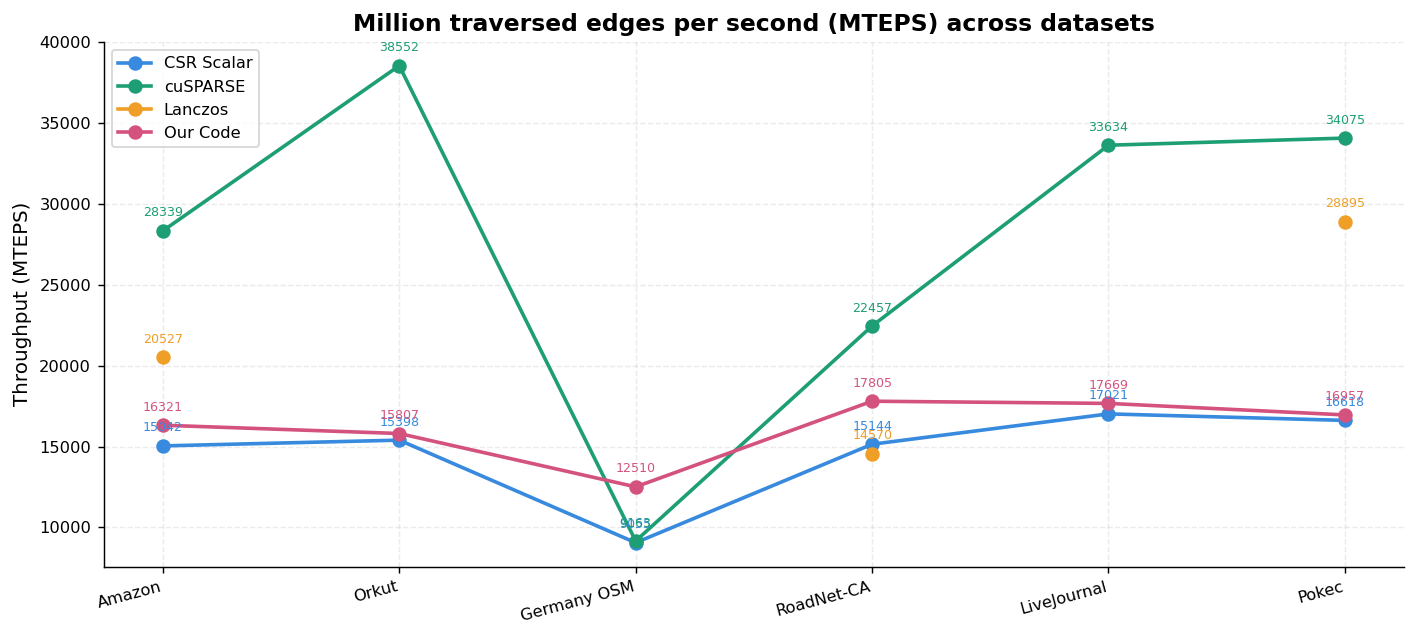

In [7]:
fig, ax = plt.subplots(figsize=(11, 5))
for m in METHODS:
    vals = [df[(df.dataset_short == ds) & (df.method_key == m)]['mteps'].values for ds in DATASETS]
    vals = [v[0] if len(v) and not np.isnan(v[0]) else np.nan for v in vals]
    ax.plot(DATASETS, vals, marker='o', color=METHOD_COLORS[m],
            label=METHOD_LABELS[m], linewidth=2, markersize=7)
    for x_val, y_val in zip(DATASETS, vals):
        if not np.isnan(y_val):
            ax.annotate(f'{y_val:.0f}', (x_val, y_val),
                        textcoords='offset points', xytext=(0, 8),
                        ha='center', fontsize=7, color=METHOD_COLORS[m])

ax.set_ylabel('Throughput (MTEPS)')
ax.set_title('Million traversed edges per second (MTEPS) across datasets')
ax.set_xticklabels(DATASETS, rotation=15, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig('plot_03_mteps_line.png', bbox_inches='tight')
plt.show()

## 4 — MTEPS vs. number of edges (scatter)

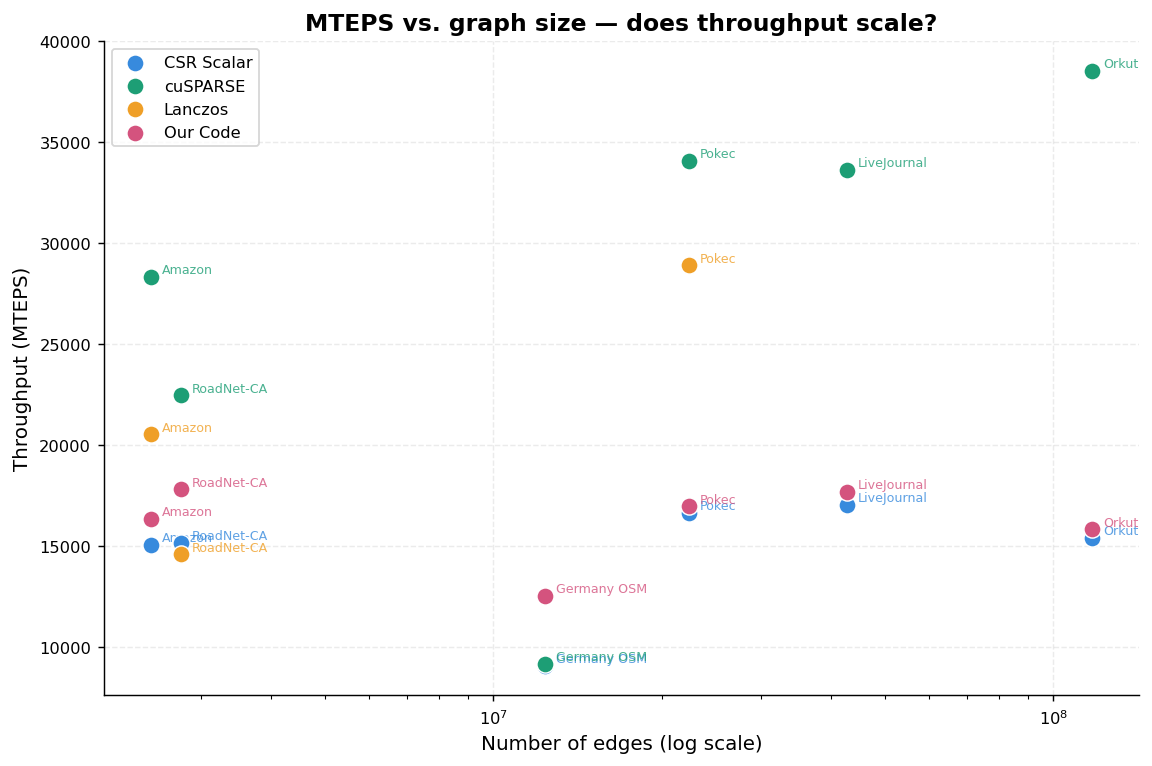

In [8]:
fig, ax = plt.subplots(figsize=(9, 6))
for m in METHODS:
    sub = df[(df.method_key == m) & df.mteps.notna() & df.num_edges.notna()]
    ax.scatter(sub.num_edges, sub.mteps, color=METHOD_COLORS[m],
               label=METHOD_LABELS[m], s=90, zorder=4, edgecolors='white', linewidth=0.8)
    for _, row in sub.iterrows():
        ax.annotate(row.dataset_short, (row.num_edges, row.mteps),
                    textcoords='offset points', xytext=(6, 2), fontsize=7,
                    color=METHOD_COLORS[m], alpha=0.8)

ax.set_xscale('log')
ax.set_xlabel('Number of edges (log scale)')
ax.set_ylabel('Throughput (MTEPS)')
ax.set_title('MTEPS vs. graph size — does throughput scale?')
ax.legend()
plt.tight_layout()
plt.savefig('plot_04_mteps_vs_edges_scatter.png', bbox_inches='tight')
plt.show()

## 5 — Speedup heatmap (method pairs)

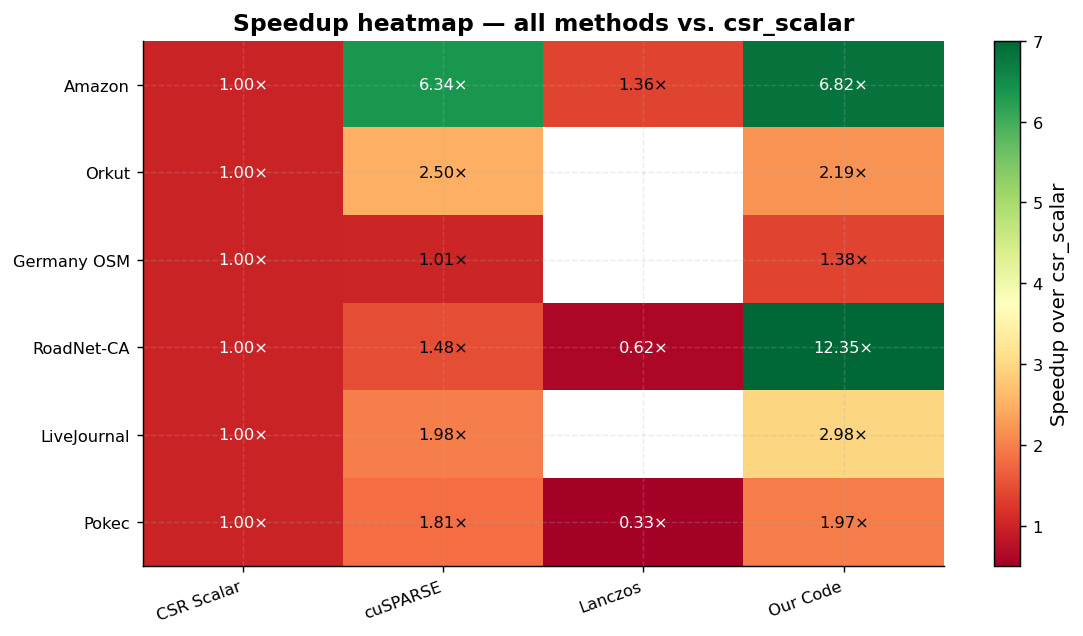

In [9]:
speedup_data = {}
for m in METHODS:
    speedup_data[METHOD_LABELS[m]] = []
    for ds in DATASETS:
        base = df[(df.dataset_short == ds) & (df.method_key == 'csr_scalar')]['execution_time_ms'].values
        comp = df[(df.dataset_short == ds) & (df.method_key == m)]['execution_time_ms'].values
        if len(base) and len(comp) and comp[0] and not np.isnan(comp[0]):
            speedup_data[METHOD_LABELS[m]].append(base[0] / comp[0])
        else:
            speedup_data[METHOD_LABELS[m]].append(np.nan)

hm_df = pd.DataFrame(speedup_data, index=DATASETS)

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(hm_df.values, cmap='RdYlGn', aspect='auto', vmin=0.5, vmax=7)
ax.set_xticks(range(len(hm_df.columns)))
ax.set_xticklabels(hm_df.columns, rotation=20, ha='right')
ax.set_yticks(range(len(DATASETS)))
ax.set_yticklabels(DATASETS)
for i in range(len(DATASETS)):
    for j in range(len(hm_df.columns)):
        v = hm_df.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.2f}×', ha='center', va='center',
                    fontsize=9, color='black' if 1 < v < 5 else 'white')
plt.colorbar(im, ax=ax, label='Speedup over csr_scalar')
ax.set_title('Speedup heatmap — all methods vs. csr_scalar')
plt.tight_layout()
plt.savefig('plot_05_speedup_heatmap.png', bbox_inches='tight')
plt.show()

## 6 — Iterations to converge (grouped bar)

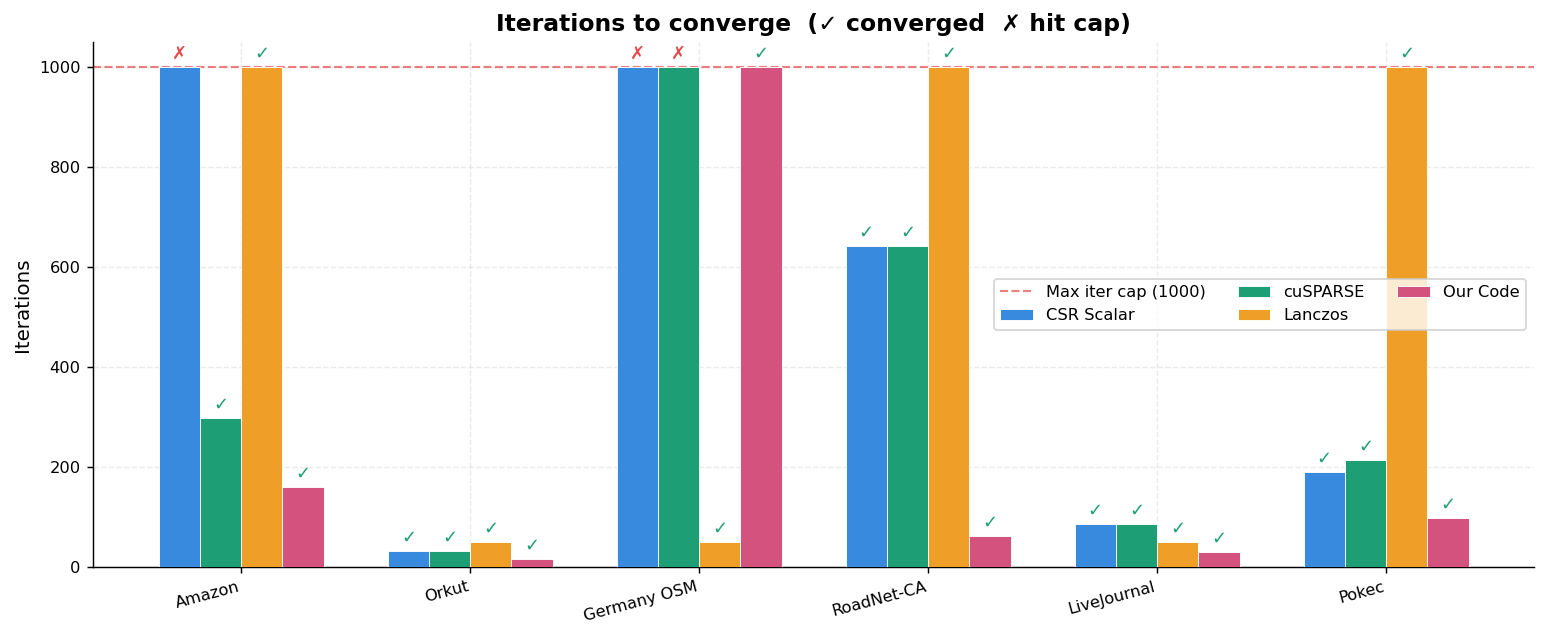

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(DATASETS))
w = 0.18
for i, m in enumerate(METHODS):
    vals, converged = [], []
    for ds in DATASETS:
        sub = df[(df.dataset_short == ds) & (df.method_key == m)]
        vals.append(sub['iterations'].values[0] if len(sub) else np.nan)
        converged.append(sub['converged'].values[0] if len(sub) else False)
    bars = ax.bar(x + i*w - 1.5*w, vals, width=w,
                  color=METHOD_COLORS[m], label=METHOD_LABELS[m],
                  zorder=3, edgecolor='white', linewidth=0.5)
    for bar, v, conv in zip(bars, vals, converged):
        if not np.isnan(v):
            marker = '✓' if conv else '✗'
            color  = '#1D9E75' if conv else '#E24B4A'
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 8, marker,
                    ha='center', va='bottom', fontsize=10, color=color)

ax.axhline(1000, color='#E24B4A', linestyle='--', linewidth=1.2, alpha=0.7, label='Max iter cap (1000)')
ax.set_xticks(x)
ax.set_xticklabels(DATASETS, rotation=15, ha='right')
ax.set_ylabel('Iterations')
ax.set_title('Iterations to converge  (✓ converged  ✗ hit cap)')
ax.legend(ncol=3)
plt.tight_layout()
plt.savefig('plot_06_iterations_bar.png', bbox_inches='tight')
plt.show()

## 7 — Convergence status heatmap

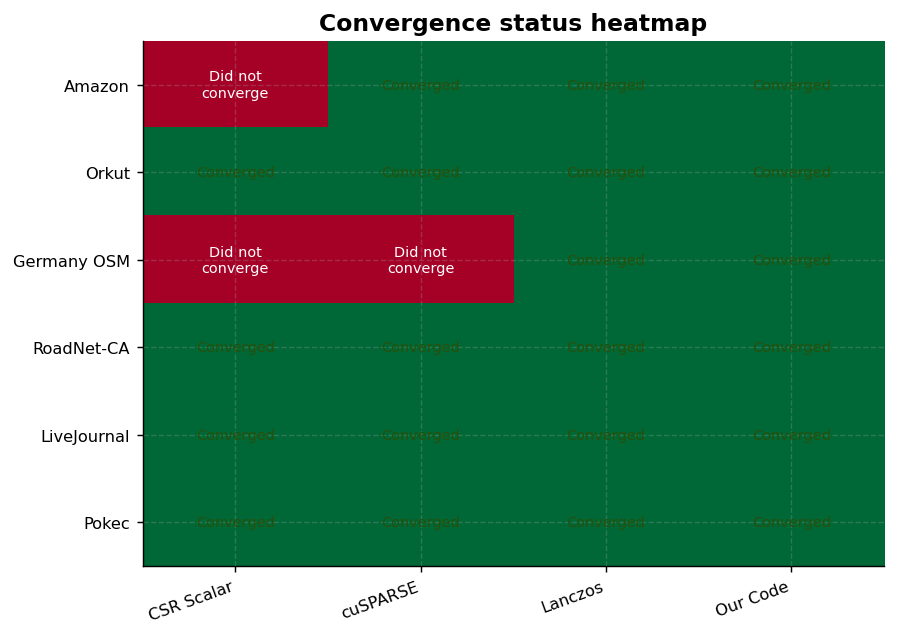

In [11]:
conv_mat = []
for ds in DATASETS:
    row_vals = []
    for m in METHODS:
        sub = df[(df.dataset_short == ds) & (df.method_key == m)]
        row_vals.append(1 if len(sub) and sub['converged'].values[0] else 0)
    conv_mat.append(row_vals)
conv_mat = np.array(conv_mat)

fig, ax = plt.subplots(figsize=(7, 5))
ax.imshow(conv_mat, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(METHODS)))
ax.set_xticklabels([METHOD_LABELS[m] for m in METHODS], rotation=20, ha='right')
ax.set_yticks(range(len(DATASETS)))
ax.set_yticklabels(DATASETS)
for i in range(len(DATASETS)):
    for j in range(len(METHODS)):
        label = 'Converged' if conv_mat[i, j] else 'Did not\nconverge'
        ax.text(j, i, label, ha='center', va='center', fontsize=8,
                color='white' if conv_mat[i, j] == 0 else '#27500A')
ax.set_title('Convergence status heatmap')
plt.tight_layout()
plt.savefig('plot_07_convergence_heatmap.png', bbox_inches='tight')
plt.show()

## 8 — Final residual vs. iterations (scatter)

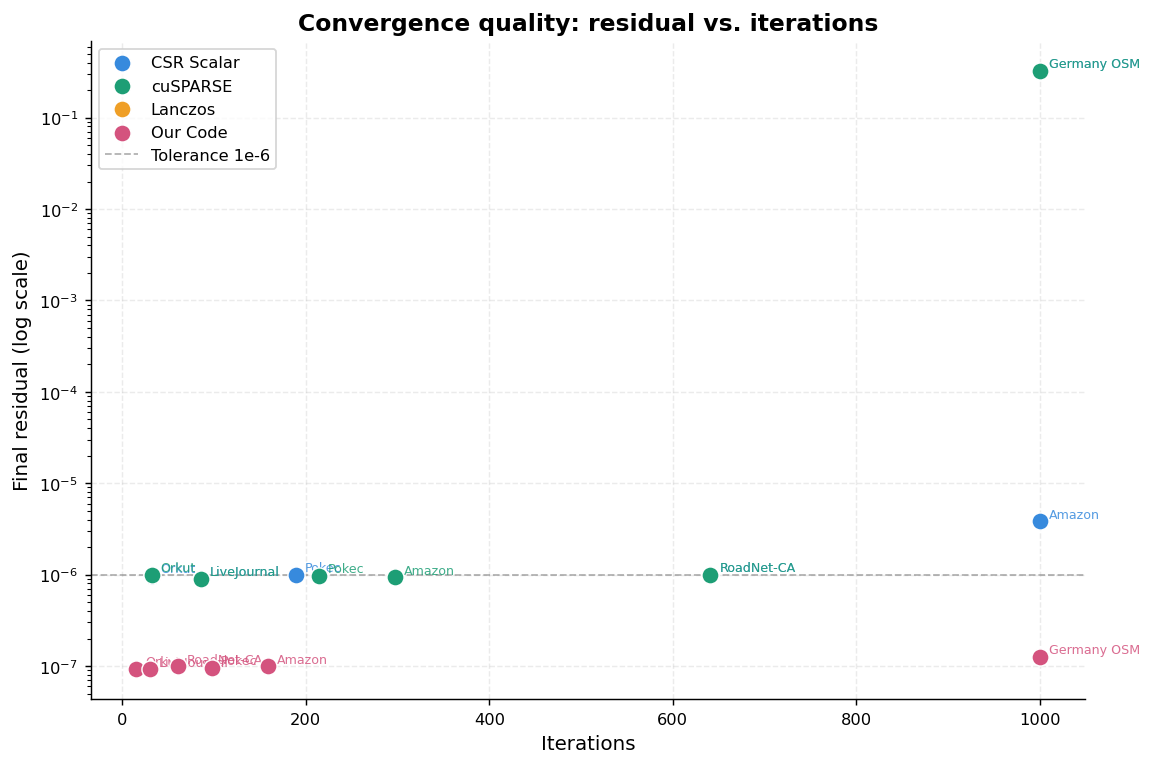

In [12]:
fig, ax = plt.subplots(figsize=(9, 6))
for m in METHODS:
    sub = df[(df.method_key == m) & df.final_residual.notna() & df.iterations.notna()]
    ax.scatter(sub.iterations, sub.final_residual,
               color=METHOD_COLORS[m], label=METHOD_LABELS[m],
               s=90, zorder=4, edgecolors='white', linewidth=0.8)
    for _, row in sub.iterrows():
        ax.annotate(row.dataset_short, (row.iterations, row.final_residual),
                    textcoords='offset points', xytext=(5, 2),
                    fontsize=7, color=METHOD_COLORS[m], alpha=0.85)

ax.set_yscale('log')
ax.set_xlabel('Iterations')
ax.set_ylabel('Final residual (log scale)')
ax.set_title('Convergence quality: residual vs. iterations')
ax.axhline(1e-6, linestyle='--', color='gray', linewidth=1, alpha=0.6, label='Tolerance 1e-6')
ax.legend()
plt.tight_layout()
plt.savefig('plot_08_residual_vs_iters.png', bbox_inches='tight')
plt.show()

## 9 — Final residual vs. execution time (Pareto — convergence)

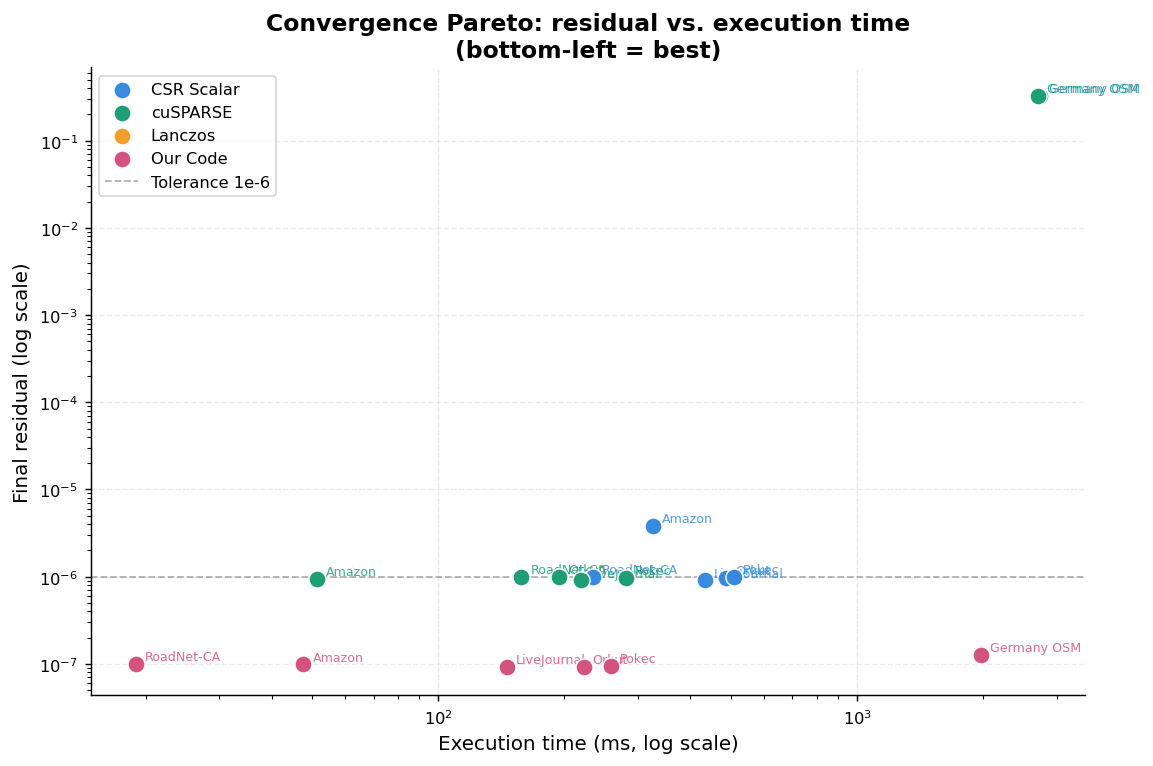

In [13]:
fig, ax = plt.subplots(figsize=(9, 6))
for m in METHODS:
    sub = df[(df.method_key == m) & df.final_residual.notna() & df.execution_time_ms.notna()]
    ax.scatter(sub.execution_time_ms, sub.final_residual,
               color=METHOD_COLORS[m], label=METHOD_LABELS[m],
               s=90, zorder=4, edgecolors='white', linewidth=0.8)
    for _, row in sub.iterrows():
        ax.annotate(row.dataset_short, (row.execution_time_ms, row.final_residual),
                    textcoords='offset points', xytext=(5, 2),
                    fontsize=7, color=METHOD_COLORS[m], alpha=0.85)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Execution time (ms, log scale)')
ax.set_ylabel('Final residual (log scale)')
ax.set_title('Convergence Pareto: residual vs. execution time\n(bottom-left = best)')
ax.axhline(1e-6, linestyle='--', color='gray', linewidth=1, alpha=0.6, label='Tolerance 1e-6')
ax.legend()
plt.tight_layout()
plt.savefig('plot_09_residual_vs_time.png', bbox_inches='tight')
plt.show()

## 10 — Reconstruction error L2 (grouped bar, log scale)

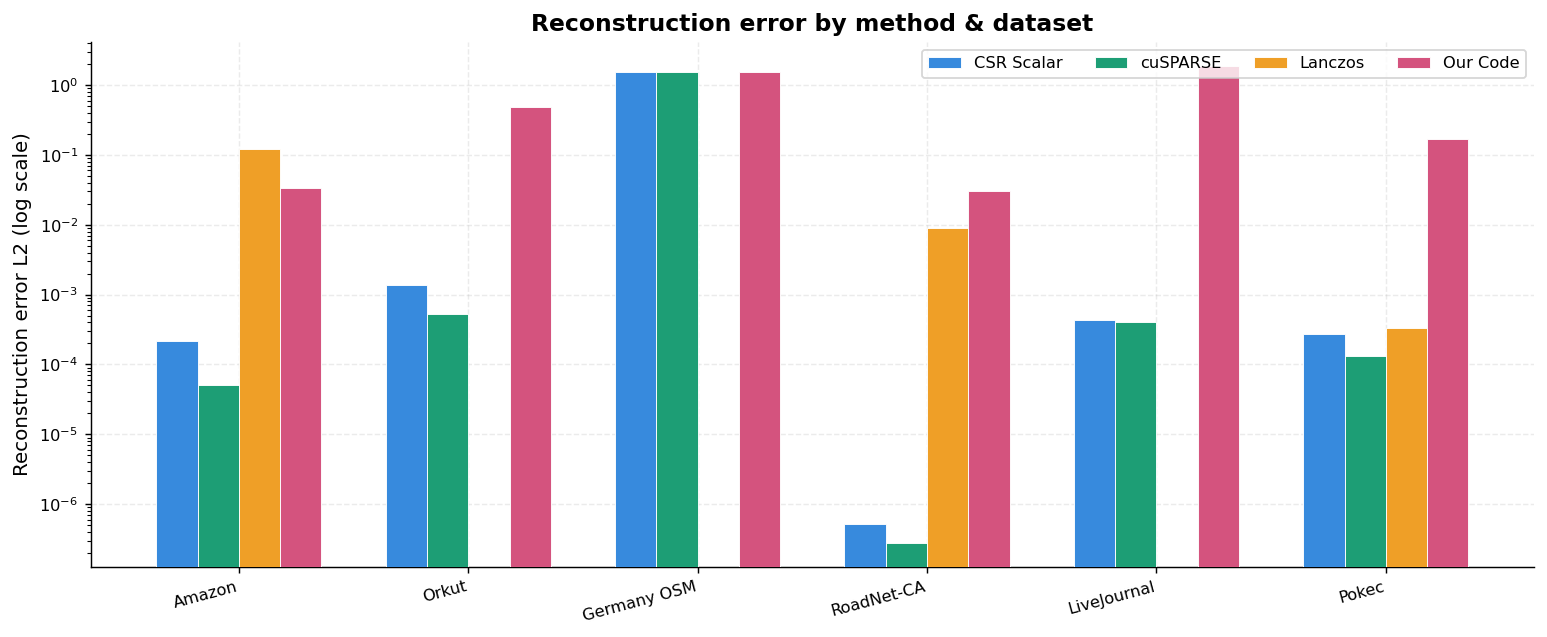

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(DATASETS))
w = 0.18
for i, m in enumerate(METHODS):
    vals = [df[(df.dataset_short == ds) & (df.method_key == m)]['reconstruction_error_l2'].values
            for ds in DATASETS]
    vals = [v[0] if len(v) and not pd.isna(v[0]) else np.nan for v in vals]
    ax.bar(x + i*w - 1.5*w, vals, width=w,
           color=METHOD_COLORS[m], label=METHOD_LABELS[m],
           zorder=3, edgecolor='white', linewidth=0.5)

ax.set_yscale('log')
ax.set_xticks(x)
ax.set_xticklabels(DATASETS, rotation=15, ha='right')
ax.set_ylabel('Reconstruction error L2 (log scale)')
ax.set_title('Reconstruction error by method & dataset')
ax.legend(ncol=4)
plt.tight_layout()
plt.savefig('plot_10_recon_error_bar.png', bbox_inches='tight')
plt.show()

## 11 — Reconstruction error heatmap

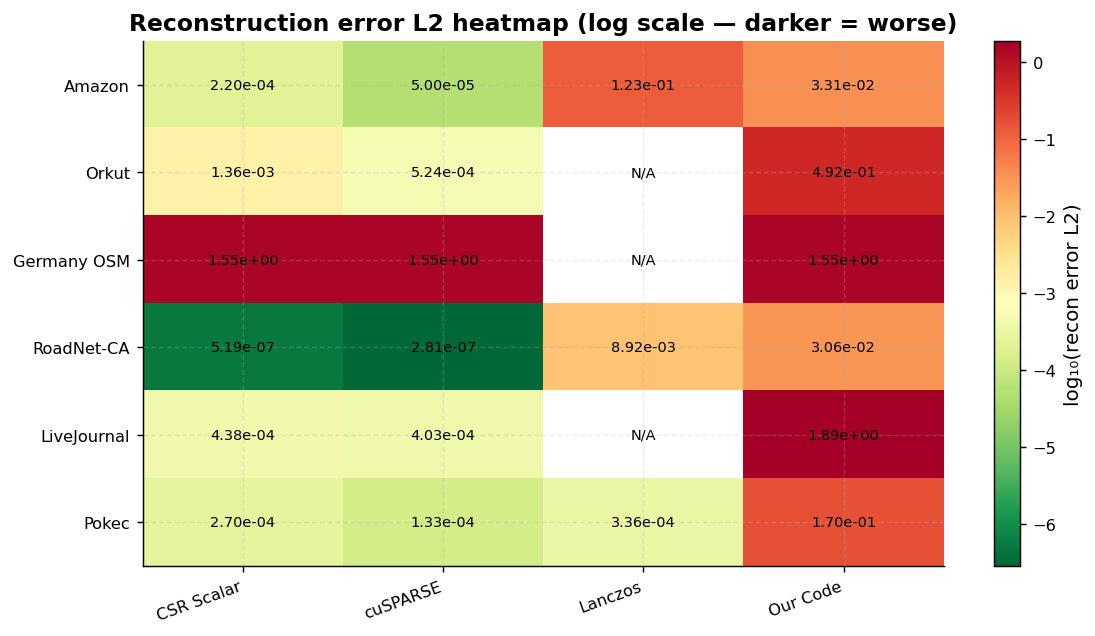

In [15]:
err_mat = []
for ds in DATASETS:
    row_vals = []
    for m in METHODS:
        sub = df[(df.dataset_short == ds) & (df.method_key == m)]
        v = sub['reconstruction_error_l2'].values
        row_vals.append(v[0] if len(v) and not pd.isna(v[0]) else np.nan)
    err_mat.append(row_vals)
err_mat = np.array(err_mat, dtype=float)
log_mat = np.where(err_mat > 0, np.log10(err_mat), np.nan)

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(log_mat, cmap='RdYlGn_r', aspect='auto')
ax.set_xticks(range(len(METHODS)))
ax.set_xticklabels([METHOD_LABELS[m] for m in METHODS], rotation=20, ha='right')
ax.set_yticks(range(len(DATASETS)))
ax.set_yticklabels(DATASETS)
for i in range(len(DATASETS)):
    for j in range(len(METHODS)):
        v = err_mat[i, j]
        label = f'{v:.2e}' if not np.isnan(v) else 'N/A'
        ax.text(j, i, label, ha='center', va='center', fontsize=8)
plt.colorbar(im, ax=ax, label='log₁₀(recon error L2)')
ax.set_title('Reconstruction error L2 heatmap (log scale — darker = worse)')
plt.tight_layout()
plt.savefig('plot_11_recon_error_heatmap.png', bbox_inches='tight')
plt.show()

## 12 — Accuracy Pareto: recon error vs. execution time

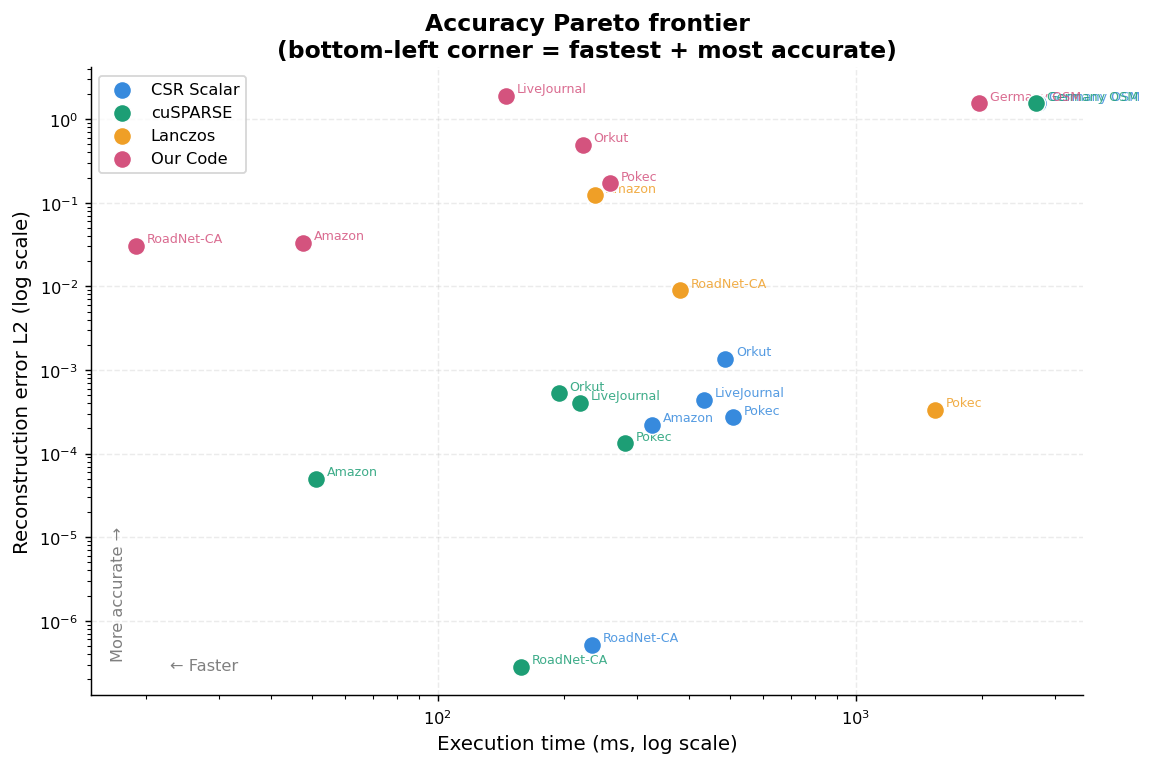

In [16]:
fig, ax = plt.subplots(figsize=(9, 6))
for m in METHODS:
    sub = df[(df.method_key == m)
             & df.reconstruction_error_l2.notna()
             & df.execution_time_ms.notna()]
    ax.scatter(sub.execution_time_ms, sub.reconstruction_error_l2,
               color=METHOD_COLORS[m], label=METHOD_LABELS[m],
               s=100, zorder=4, edgecolors='white', linewidth=0.8)
    for _, row in sub.iterrows():
        ax.annotate(row.dataset_short, (row.execution_time_ms, row.reconstruction_error_l2),
                    textcoords='offset points', xytext=(6, 2),
                    fontsize=7, color=METHOD_COLORS[m], alpha=0.85)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Execution time (ms, log scale)')
ax.set_ylabel('Reconstruction error L2 (log scale)')
ax.set_title('Accuracy Pareto frontier\n(bottom-left corner = fastest + most accurate)')
ax.legend()
ax.annotate('← Faster', xy=(0.08, 0.04), xycoords='axes fraction', fontsize=9, color='gray')
ax.annotate('More accurate →', xy=(0.02, 0.06), xycoords='axes fraction',
            fontsize=9, color='gray', rotation=90)
plt.tight_layout()
plt.savefig('plot_12_accuracy_pareto.png', bbox_inches='tight')
plt.show()

## 13 — Top eigenscore comparison (grouped bar)

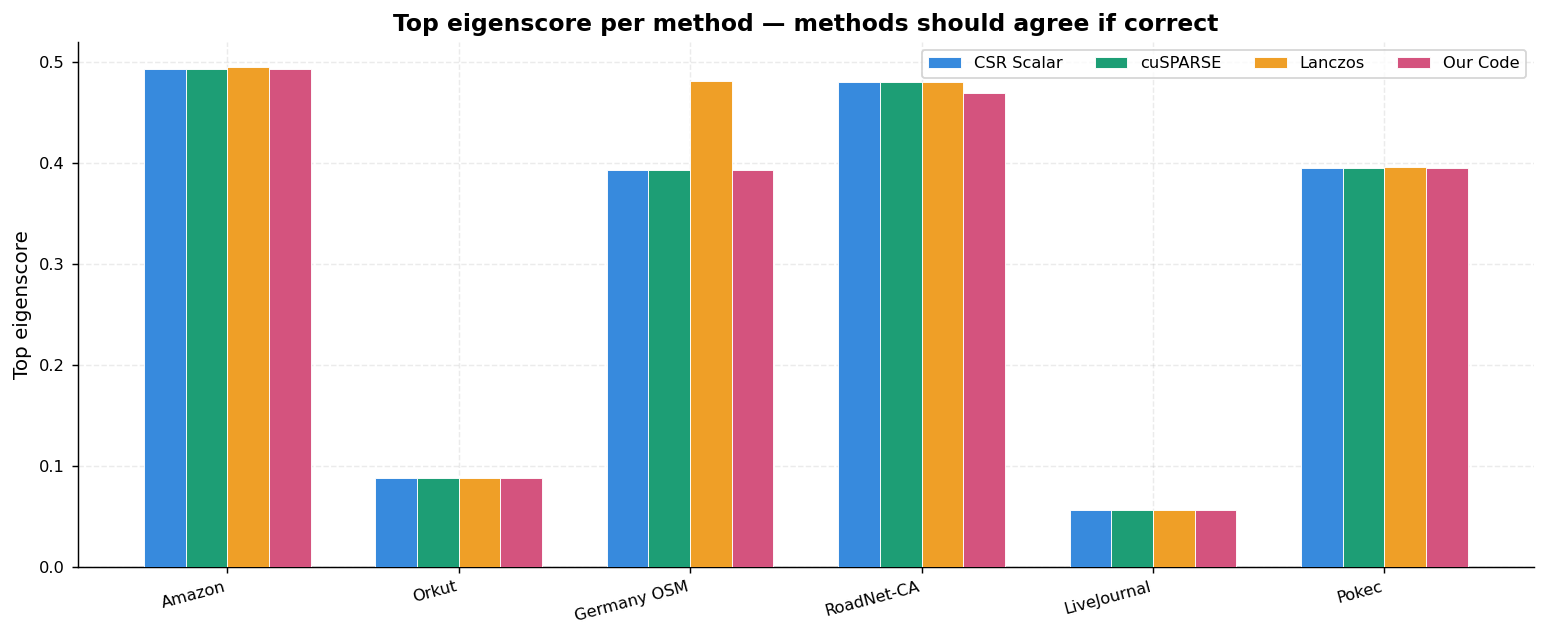

In [17]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(DATASETS))
w = 0.18
for i, m in enumerate(METHODS):
    vals = [df[(df.dataset_short == ds) & (df.method_key == m)]['top_score'].values
            for ds in DATASETS]
    vals = [v[0] if len(v) else np.nan for v in vals]
    ax.bar(x + i*w - 1.5*w, vals, width=w,
           color=METHOD_COLORS[m], label=METHOD_LABELS[m],
           zorder=3, edgecolor='white', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(DATASETS, rotation=15, ha='right')
ax.set_ylabel('Top eigenscore')
ax.set_title('Top eigenscore per method — methods should agree if correct')
ax.legend(ncol=4)
plt.tight_layout()
plt.savefig('plot_13_top_score_bar.png', bbox_inches='tight')
plt.show()

## 14 — Bandwidth utilisation (stacked: used vs. unused)

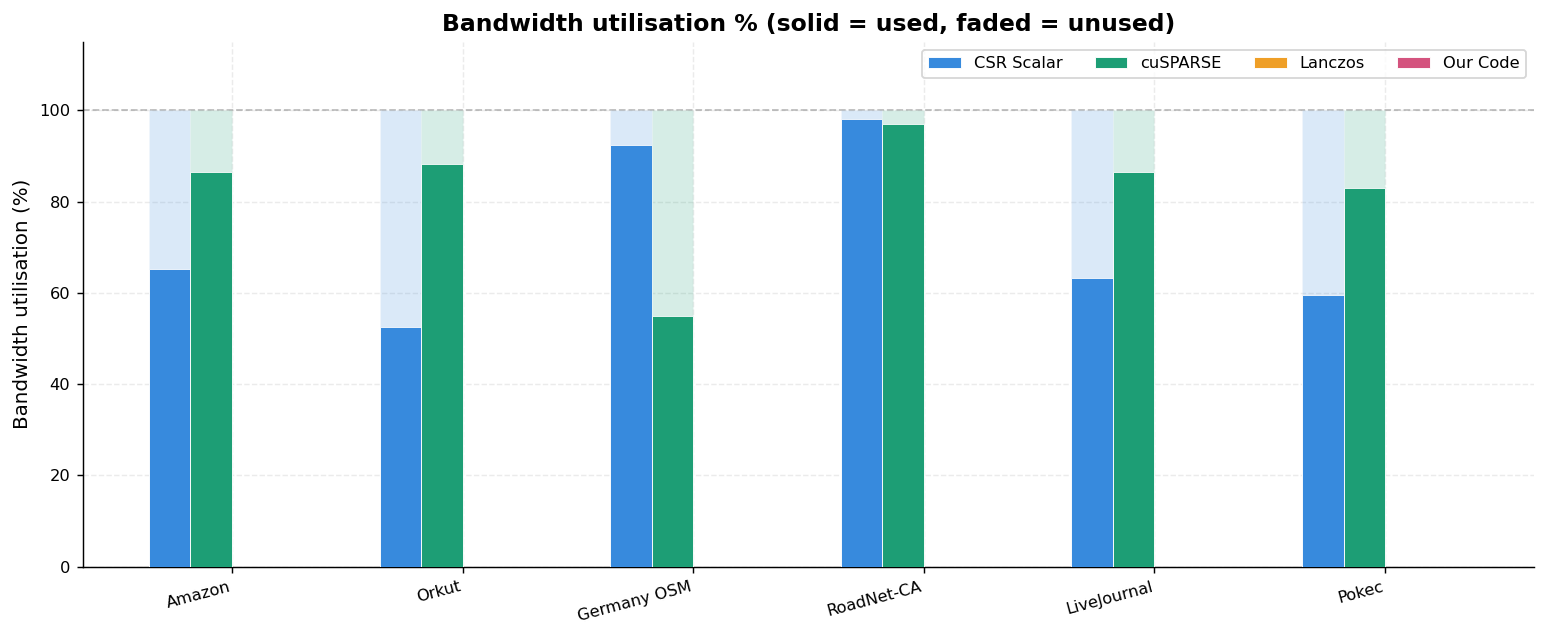

In [18]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(DATASETS))
w = 0.18
for i, m in enumerate(METHODS):
    used, peak_bw = [], []
    for ds in DATASETS:
        sub = df[(df.dataset_short == ds) & (df.method_key == m)]
        bw_util = sub['bw_util_percent'].values
        pk = sub['peak_bandwidth_gbps'].values
        if len(bw_util) and not pd.isna(bw_util[0]):
            used.append(bw_util[0])
            peak_bw.append(100 - bw_util[0])
        else:
            used.append(0)
            peak_bw.append(0)
    offset = x + i*w - 1.5*w
    ax.bar(offset, used, width=w, color=METHOD_COLORS[m],
           label=METHOD_LABELS[m], zorder=3, edgecolor='white', linewidth=0.5)
    ax.bar(offset, peak_bw, width=w, bottom=used,
           color=METHOD_COLORS[m], alpha=0.18, zorder=3, edgecolor='white', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(DATASETS, rotation=15, ha='right')
ax.set_ylabel('Bandwidth utilisation (%)')
ax.set_ylim(0, 115)
ax.axhline(100, linestyle='--', color='gray', linewidth=1, alpha=0.5)
ax.set_title('Bandwidth utilisation % (solid = used, faded = unused)')
ax.legend(ncol=4)
plt.tight_layout()
plt.savefig('plot_14_bw_util_stacked.png', bbox_inches='tight')
plt.show()

## 15 — Bandwidth util vs. MTEPS (scatter)

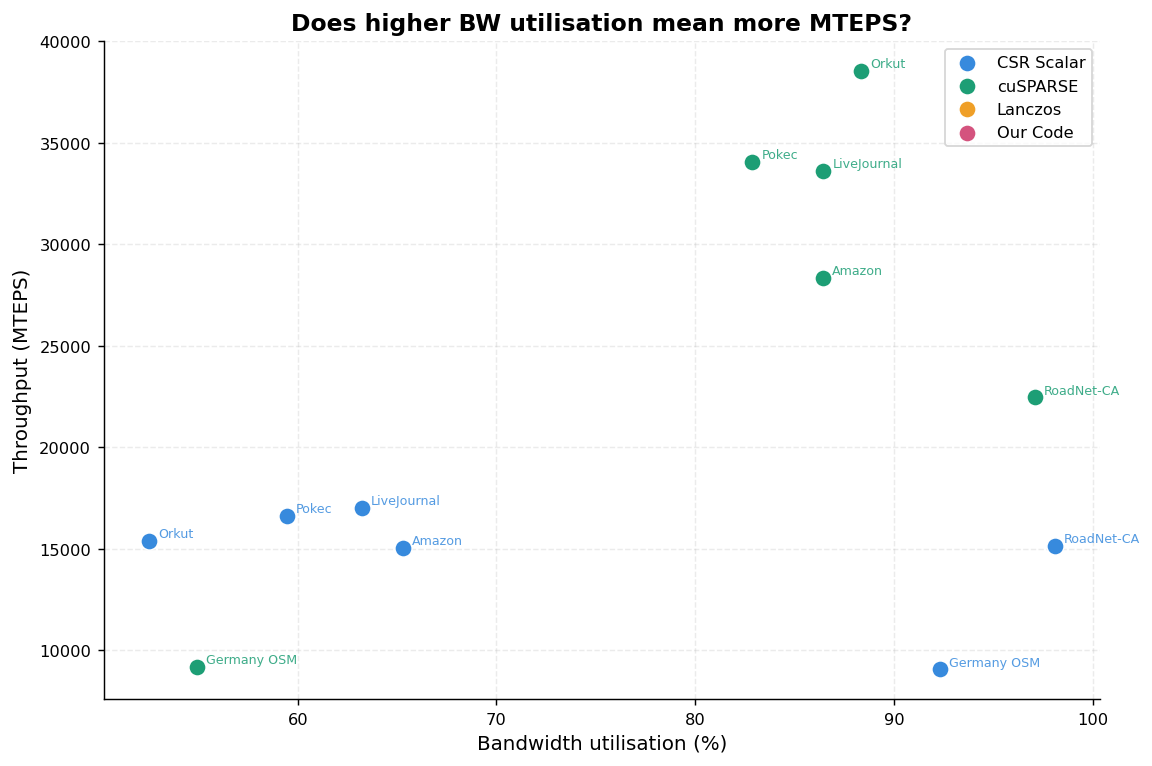

In [19]:
fig, ax = plt.subplots(figsize=(9, 6))
for m in METHODS:
    sub = df[(df.method_key == m) & df.bw_util_percent.notna() & df.mteps.notna()]
    ax.scatter(sub.bw_util_percent, sub.mteps,
               color=METHOD_COLORS[m], label=METHOD_LABELS[m],
               s=90, zorder=4, edgecolors='white', linewidth=0.8)
    for _, row in sub.iterrows():
        ax.annotate(row.dataset_short, (row.bw_util_percent, row.mteps),
                    textcoords='offset points', xytext=(5, 2),
                    fontsize=7, color=METHOD_COLORS[m], alpha=0.85)

ax.set_xlabel('Bandwidth utilisation (%)')
ax.set_ylabel('Throughput (MTEPS)')
ax.set_title('Does higher BW utilisation mean more MTEPS?')
ax.legend()
plt.tight_layout()
plt.savefig('plot_15_bw_vs_mteps.png', bbox_inches='tight')
plt.show()

## 16 — Effective GFLOPS (line chart)

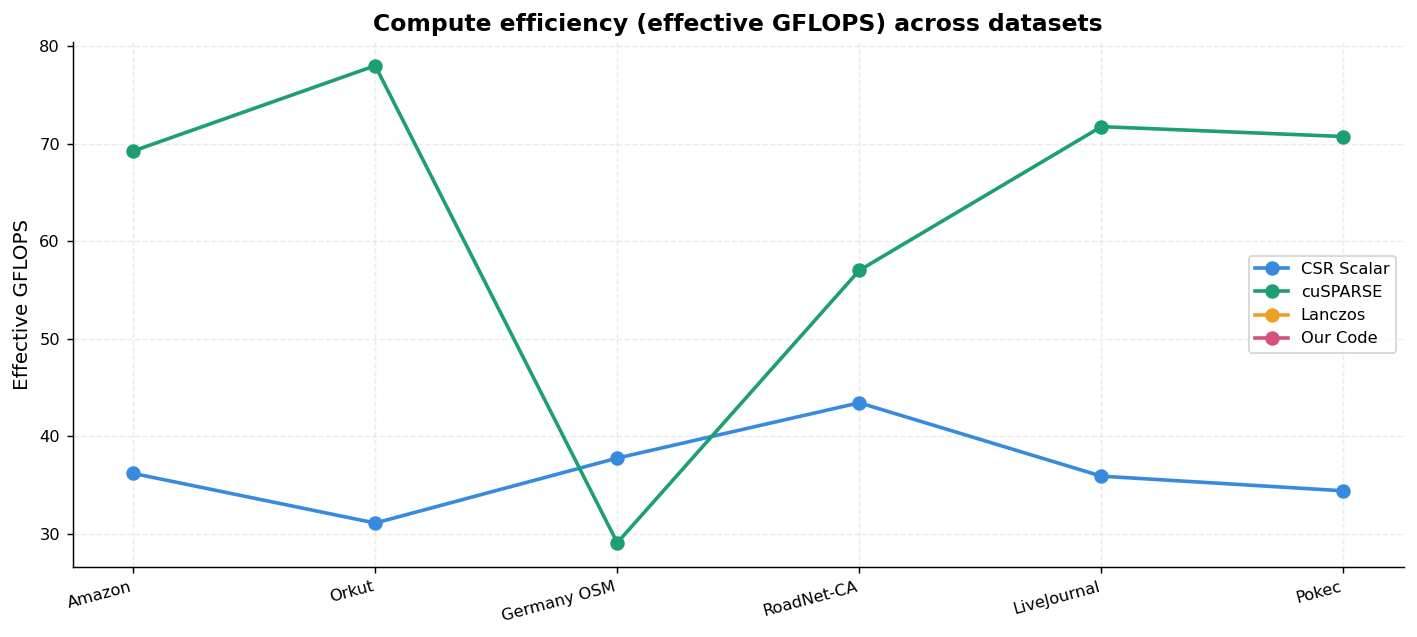

In [20]:
fig, ax = plt.subplots(figsize=(11, 5))
for m in METHODS:
    vals = [df[(df.dataset_short == ds) & (df.method_key == m)]['effective_gflops'].values
            for ds in DATASETS]
    vals = [v[0] if len(v) and not pd.isna(v[0]) else np.nan for v in vals]
    ax.plot(DATASETS, vals, marker='o', color=METHOD_COLORS[m],
            label=METHOD_LABELS[m], linewidth=2, markersize=7)

ax.set_ylabel('Effective GFLOPS')
ax.set_title('Compute efficiency (effective GFLOPS) across datasets')
ax.set_xticklabels(DATASETS, rotation=15, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig('plot_16_gflops_line.png', bbox_inches='tight')
plt.show()

## 17 — Memory footprint (grouped bar)

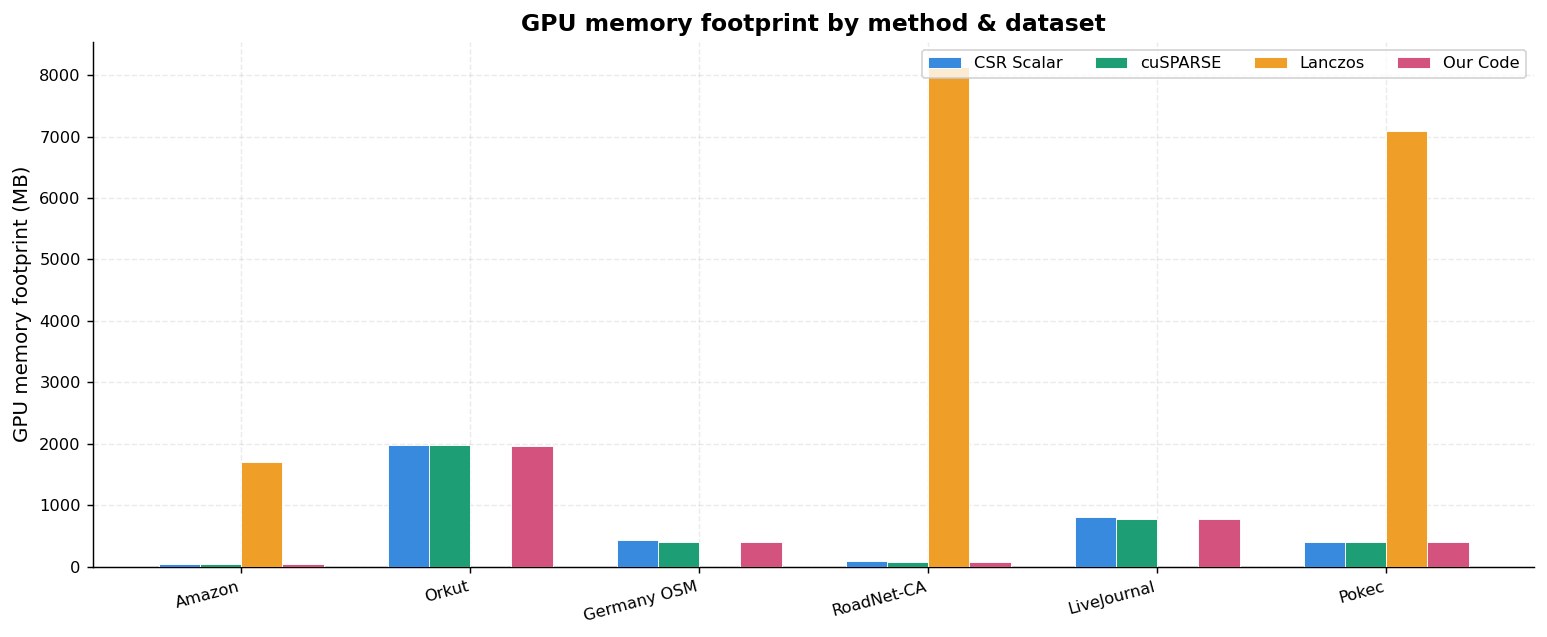

In [21]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(DATASETS))
w = 0.18
for i, m in enumerate(METHODS):
    vals = [df[(df.dataset_short == ds) & (df.method_key == m)]['memory_footprint_gb'].values
            for ds in DATASETS]
    vals = [v[0]*1024 if len(v) and not pd.isna(v[0]) else np.nan for v in vals]  # to MB
    ax.bar(x + i*w - 1.5*w, vals, width=w,
           color=METHOD_COLORS[m], label=METHOD_LABELS[m],
           zorder=3, edgecolor='white', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(DATASETS, rotation=15, ha='right')
ax.set_ylabel('GPU memory footprint (MB)')
ax.set_title('GPU memory footprint by method & dataset')
ax.legend(ncol=4)
plt.tight_layout()
plt.savefig('plot_17_memory_bar.png', bbox_inches='tight')
plt.show()

## 18 — Time breakdown: SpMV · Normalize · H2D · D2H (stacked bar, csr_scalar)

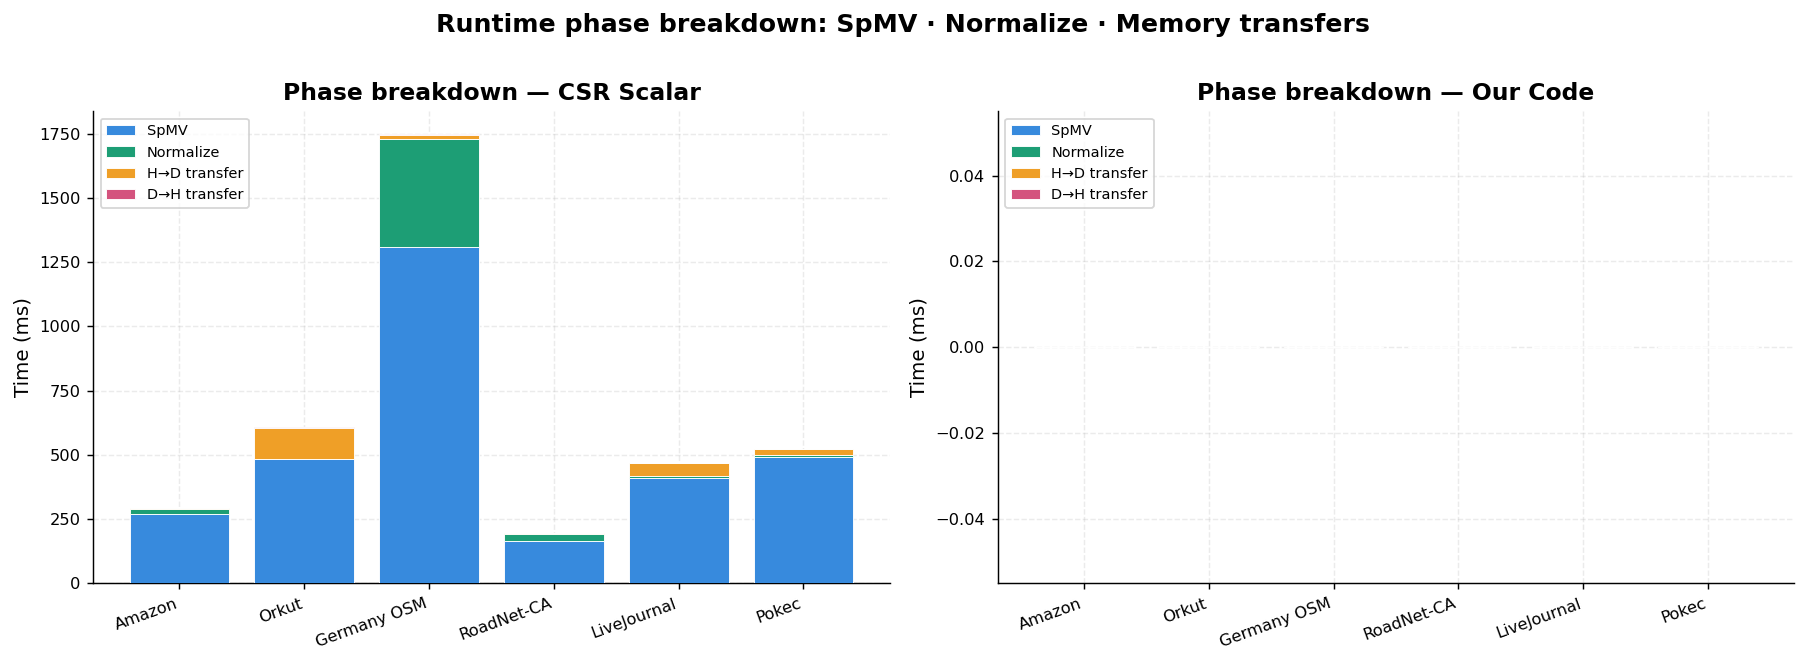

In [22]:
phase_colors = {'spmv_ms': '#378ADD', 'normalize_ms': '#1D9E75',
                'h2d_ms': '#EF9F27', 'd2h_ms': '#D4537E'}
phase_labels = {'spmv_ms': 'SpMV', 'normalize_ms': 'Normalize',
                'h2d_ms': 'H→D transfer', 'd2h_ms': 'D→H transfer'}
phases = list(phase_colors.keys())

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
for ax_idx, target_method in enumerate(['csr_scalar', 'our_code']):
    ax = axes[ax_idx]
    bottoms = np.zeros(len(DATASETS))
    for ph in phases:
        vals = []
        for ds in DATASETS:
            sub = df[(df.dataset_short == ds) & (df.method_key == target_method)]
            v = sub[ph].values
            vals.append(v[0] if len(v) and not pd.isna(v[0]) else 0)
        vals = np.array(vals)
        ax.bar(DATASETS, vals, bottom=bottoms, color=phase_colors[ph],
               label=phase_labels[ph], zorder=3, edgecolor='white', linewidth=0.5)
        bottoms += vals
    ax.set_title(f'Phase breakdown — {METHOD_LABELS[target_method]}')
    ax.set_xticklabels(DATASETS, rotation=20, ha='right')
    ax.set_ylabel('Time (ms)')
    ax.legend(loc='upper left', fontsize=8)

plt.suptitle('Runtime phase breakdown: SpMV · Normalize · Memory transfers', y=1.01)
plt.tight_layout()
plt.savefig('plot_18_phase_breakdown.png', bbox_inches='tight')
plt.show()

## 19 — Average iteration time (grouped bar)

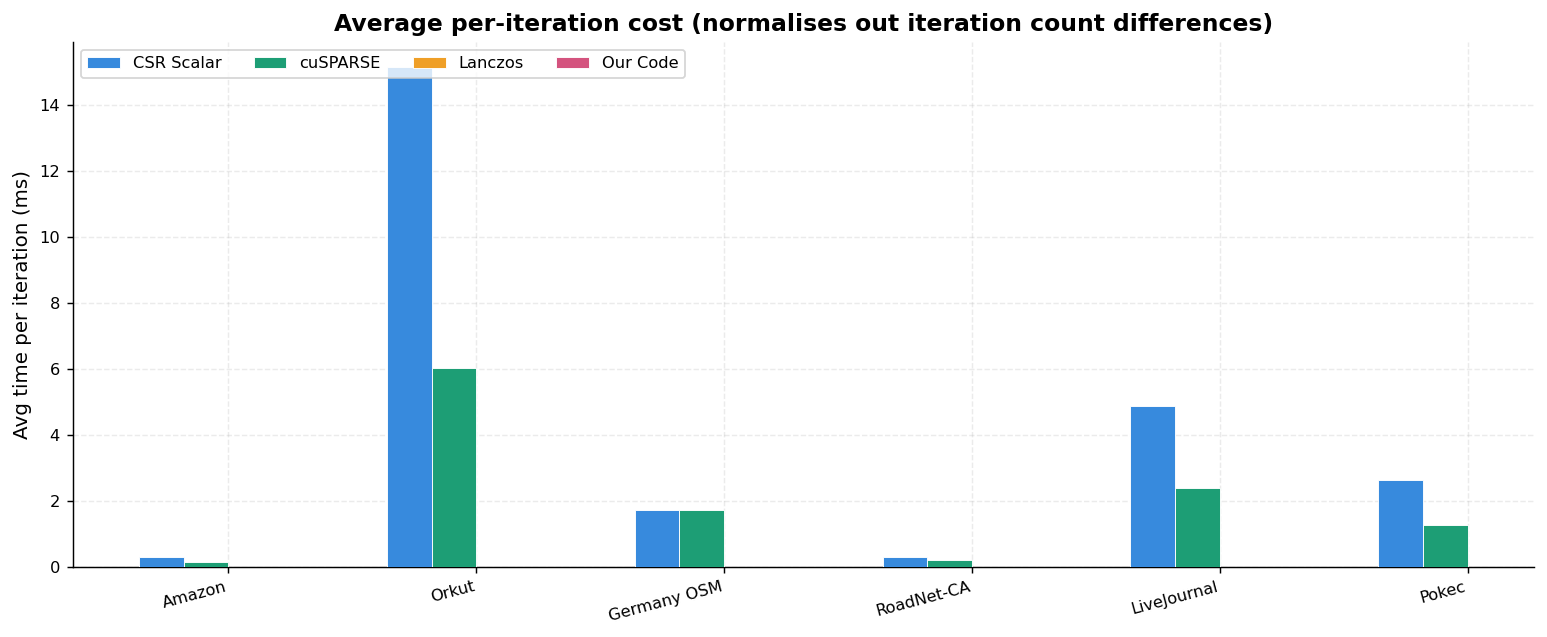

In [23]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(DATASETS))
w = 0.18
for i, m in enumerate(METHODS):
    vals = [df[(df.dataset_short == ds) & (df.method_key == m)]['avg_iter_ms'].values
            for ds in DATASETS]
    vals = [v[0] if len(v) and not pd.isna(v[0]) else np.nan for v in vals]
    ax.bar(x + i*w - 1.5*w, vals, width=w,
           color=METHOD_COLORS[m], label=METHOD_LABELS[m],
           zorder=3, edgecolor='white', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(DATASETS, rotation=15, ha='right')
ax.set_ylabel('Avg time per iteration (ms)')
ax.set_title('Average per-iteration cost (normalises out iteration count differences)')
ax.legend(ncol=4)
plt.tight_layout()
plt.savefig('plot_19_avg_iter_ms.png', bbox_inches='tight')
plt.show()

## 20 — SpMV time vs. NNZ (scatter)

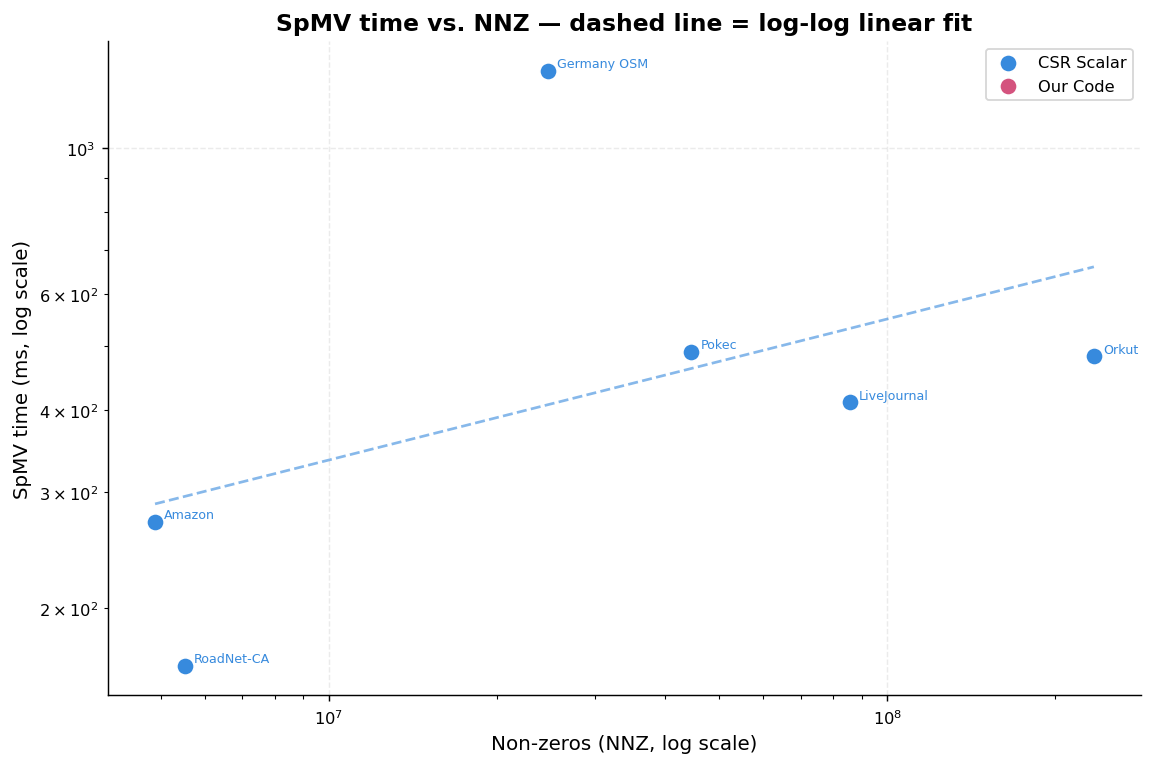

In [24]:
fig, ax = plt.subplots(figsize=(9, 6))
for m in ['csr_scalar', 'our_code']:
    sub = df[(df.method_key == m) & df.spmv_ms.notna() & df.nnz.notna()]
    ax.scatter(sub.nnz, sub.spmv_ms, color=METHOD_COLORS[m],
               label=METHOD_LABELS[m], s=90, zorder=4,
               edgecolors='white', linewidth=0.8)
    # linear fit
    if len(sub) > 1:
        z = np.polyfit(np.log10(sub.nnz), np.log10(sub.spmv_ms), 1)
        x_fit = np.linspace(sub.nnz.min(), sub.nnz.max(), 100)
        y_fit = 10**np.polyval(z, np.log10(x_fit))
        ax.plot(x_fit, y_fit, color=METHOD_COLORS[m], linewidth=1.5, linestyle='--', alpha=0.6)
    for _, row in sub.iterrows():
        ax.annotate(row.dataset_short, (row.nnz, row.spmv_ms),
                    textcoords='offset points', xytext=(5, 2),
                    fontsize=7, color=METHOD_COLORS[m])

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Non-zeros (NNZ, log scale)')
ax.set_ylabel('SpMV time (ms, log scale)')
ax.set_title('SpMV time vs. NNZ — dashed line = log-log linear fit')
ax.legend()
plt.tight_layout()
plt.savefig('plot_20_spmv_vs_nnz.png', bbox_inches='tight')
plt.show()

## 21 — Execution time vs. graph density (scatter)

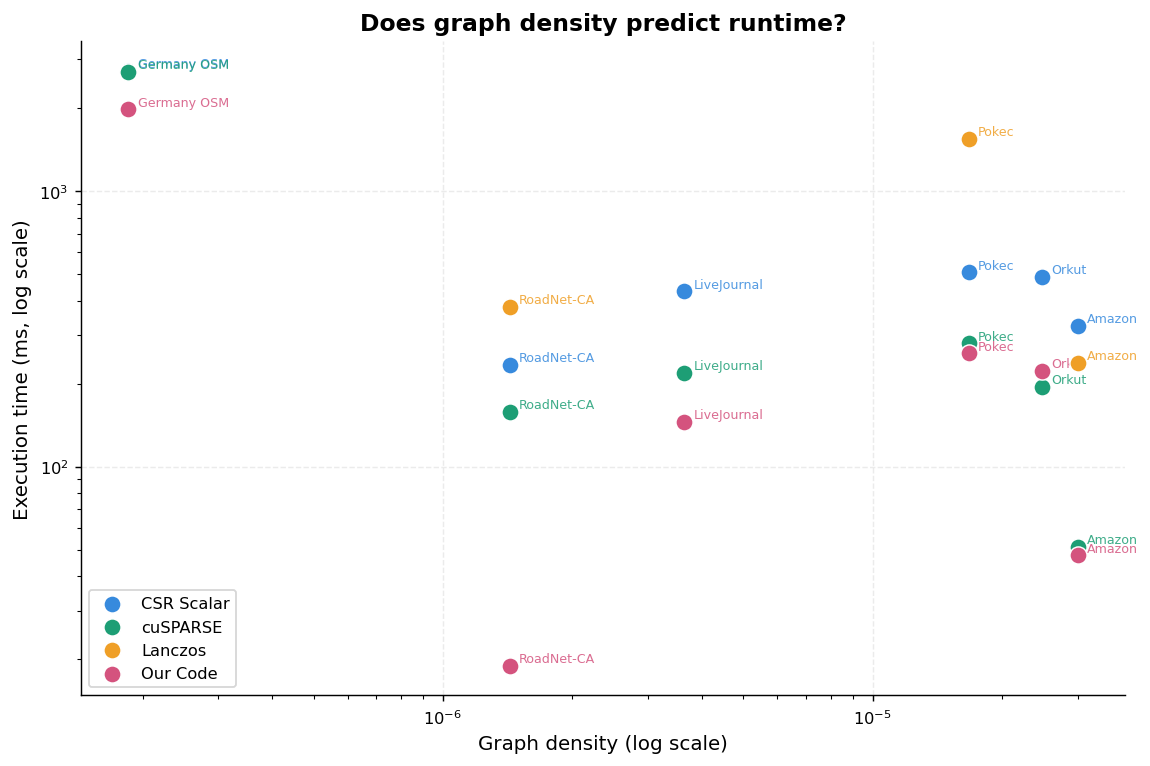

In [25]:
fig, ax = plt.subplots(figsize=(9, 6))
for m in METHODS:
    sub = df[(df.method_key == m) & df.density.notna() & df.execution_time_ms.notna()]
    ax.scatter(sub.density, sub.execution_time_ms,
               color=METHOD_COLORS[m], label=METHOD_LABELS[m],
               s=90, zorder=4, edgecolors='white', linewidth=0.8)
    for _, row in sub.iterrows():
        ax.annotate(row.dataset_short, (row.density, row.execution_time_ms),
                    textcoords='offset points', xytext=(5, 2),
                    fontsize=7, color=METHOD_COLORS[m], alpha=0.85)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Graph density (log scale)')
ax.set_ylabel('Execution time (ms, log scale)')
ax.set_title('Does graph density predict runtime?')
ax.legend()
plt.tight_layout()
plt.savefig('plot_21_exec_vs_density.png', bbox_inches='tight')
plt.show()

## 22 — Exec time vs. num_edges (scaling plot)

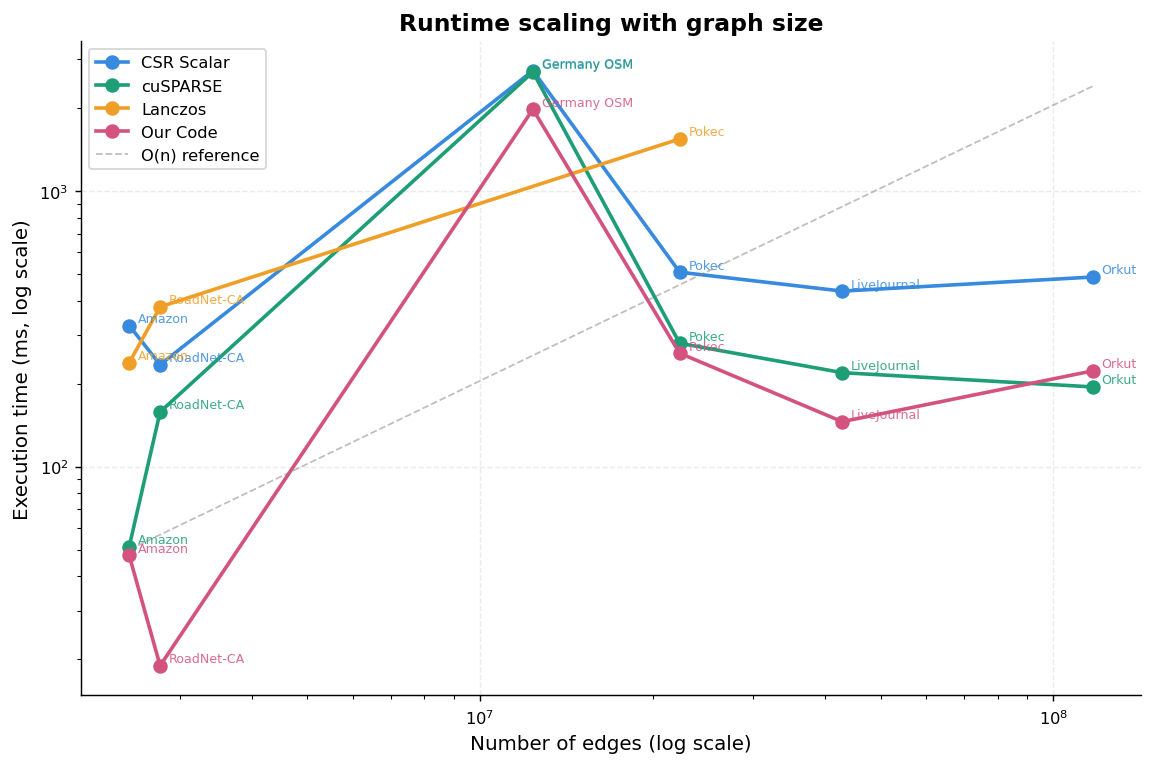

In [26]:
fig, ax = plt.subplots(figsize=(9, 6))
for m in METHODS:
    sub = df[(df.method_key == m) & df.num_edges.notna() & df.execution_time_ms.notna()]
    sub_sorted = sub.sort_values('num_edges')
    ax.plot(sub_sorted.num_edges, sub_sorted.execution_time_ms,
            marker='o', color=METHOD_COLORS[m], label=METHOD_LABELS[m],
            linewidth=2, markersize=7)
    for _, row in sub.iterrows():
        ax.annotate(row.dataset_short, (row.num_edges, row.execution_time_ms),
                    textcoords='offset points', xytext=(5, 2),
                    fontsize=7, color=METHOD_COLORS[m], alpha=0.85)

# reference O(n) line
edges = df['num_edges'].dropna().sort_values().unique()
ref_y = edges / edges[0] * 50
ax.plot(edges, ref_y, '--', color='gray', linewidth=1, alpha=0.5, label='O(n) reference')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Number of edges (log scale)')
ax.set_ylabel('Execution time (ms, log scale)')
ax.set_title('Runtime scaling with graph size')
ax.legend()
plt.tight_layout()
plt.savefig('plot_22_scaling.png', bbox_inches='tight')
plt.show()

## 23 — Bubble chart: iterations × residual × exec time

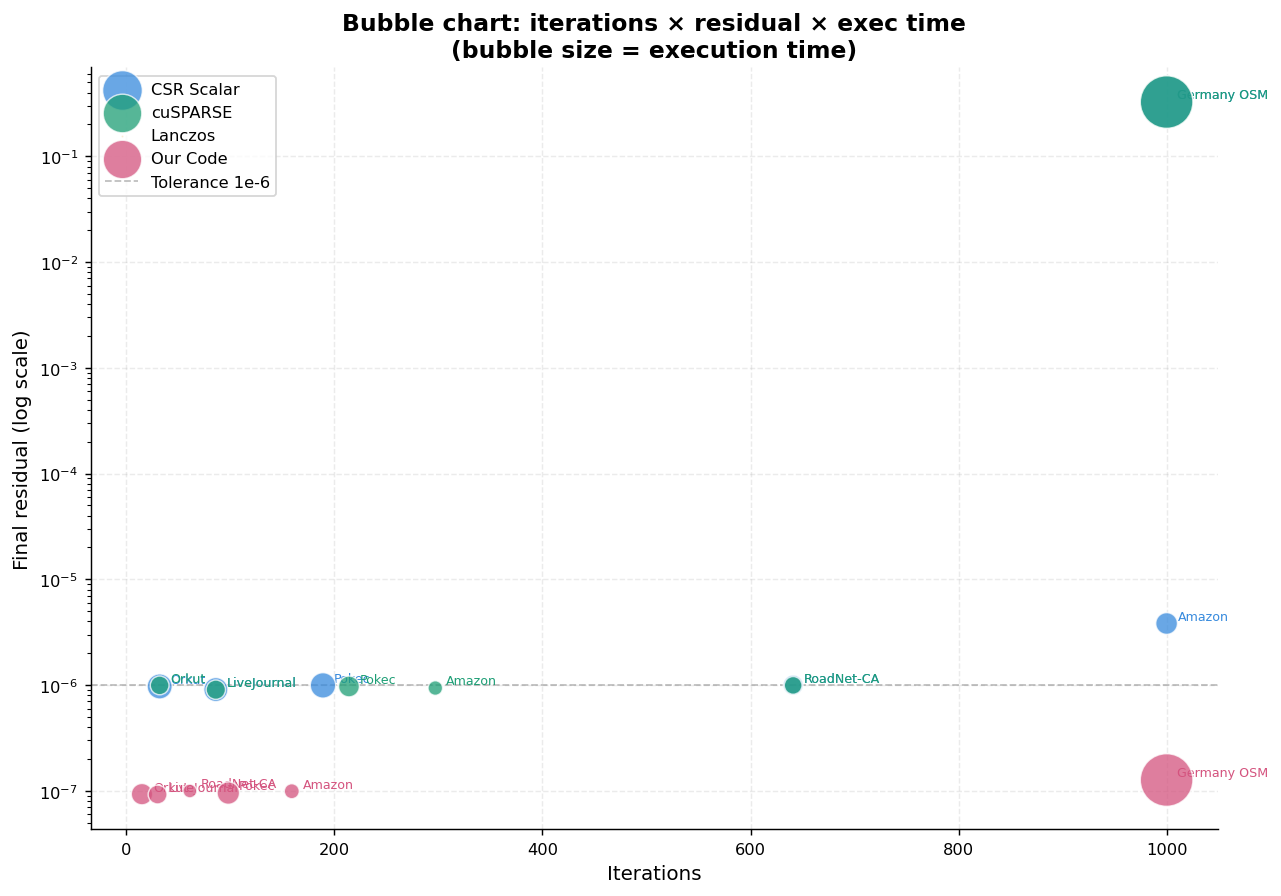

In [27]:
fig, ax = plt.subplots(figsize=(10, 7))
for m in METHODS:
    sub = df[(df.method_key == m)
             & df.iterations.notna()
             & df.final_residual.notna()
             & df.execution_time_ms.notna()]
    sizes = (sub.execution_time_ms / sub.execution_time_ms.max() * 800 + 50)
    ax.scatter(sub.iterations, sub.final_residual,
               s=sizes, color=METHOD_COLORS[m],
               label=METHOD_LABELS[m], alpha=0.75,
               zorder=4, edgecolors='white', linewidth=0.8)
    for _, row in sub.iterrows():
        ax.annotate(row.dataset_short,
                    (row.iterations, row.final_residual),
                    textcoords='offset points', xytext=(6, 2),
                    fontsize=7, color=METHOD_COLORS[m])

ax.set_yscale('log')
ax.set_xlabel('Iterations')
ax.set_ylabel('Final residual (log scale)')
ax.set_title('Bubble chart: iterations × residual × exec time\n(bubble size = execution time)')
ax.axhline(1e-6, linestyle='--', color='gray', linewidth=1, alpha=0.5, label='Tolerance 1e-6')
ax.legend()
plt.tight_layout()
plt.savefig('plot_23_bubble.png', bbox_inches='tight')
plt.show()

## 24 — Composite efficiency score (MTEPS / (recon_error × iterations))

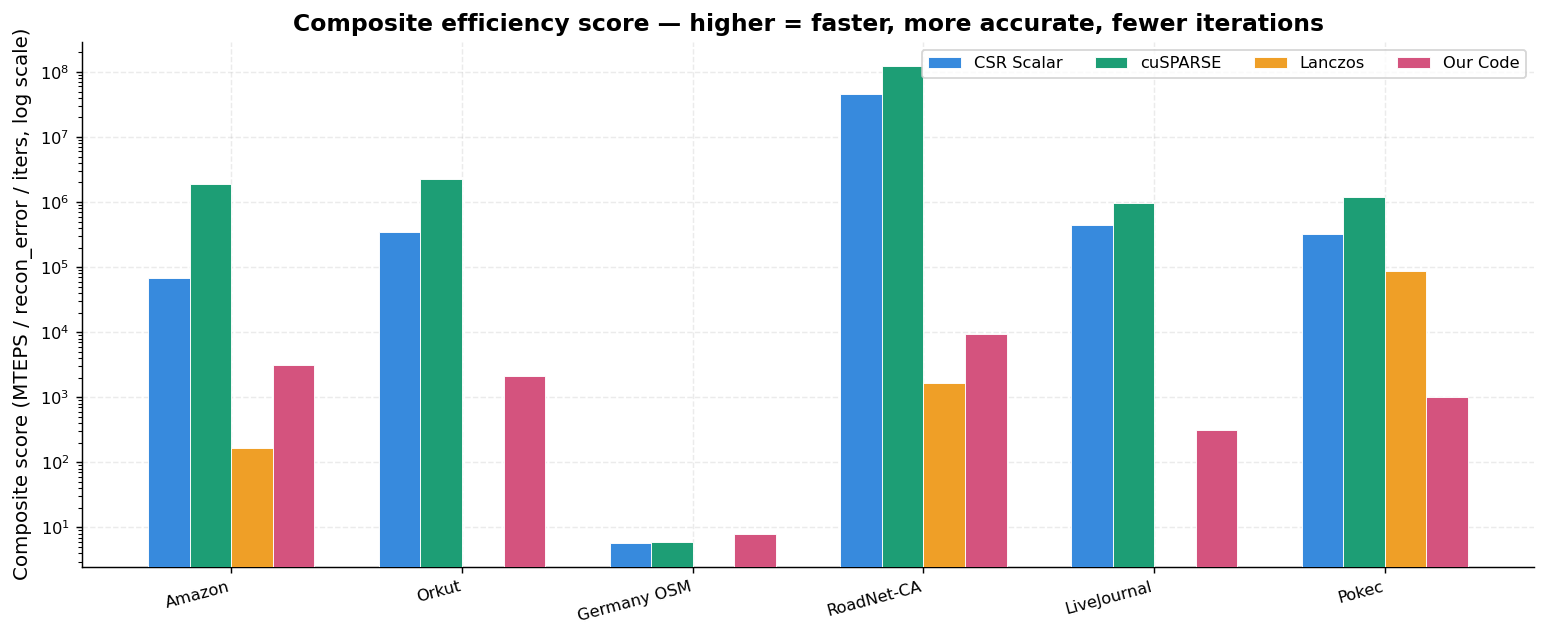

In [28]:
score_rows = []
for ds in DATASETS:
    for m in METHODS:
        sub = df[(df.dataset_short == ds) & (df.method_key == m)]
        if len(sub):
            mt = sub.mteps.values[0]
            re = sub.reconstruction_error_l2.values[0]
            it = sub.iterations.values[0]
            if pd.notna(mt) and pd.notna(re) and pd.notna(it) and re > 0 and it > 0:
                score = mt / (re * it)
                score_rows.append({'dataset': ds, 'method': m, 'score': score})

score_df = pd.DataFrame(score_rows)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(DATASETS))
w = 0.18
for i, m in enumerate(METHODS):
    vals = [score_df[(score_df.dataset == ds) & (score_df.method == m)]['score'].values
            for ds in [DS_SHORT[k] for k in raw.keys()]]
    vals = [v[0] if len(v) else np.nan for v in vals]
    ax.bar(x + i*w - 1.5*w, vals, width=w,
           color=METHOD_COLORS[m], label=METHOD_LABELS[m],
           zorder=3, edgecolor='white', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(DATASETS, rotation=15, ha='right')
ax.set_yscale('log')
ax.set_ylabel('Composite score (MTEPS / recon_error / iters, log scale)')
ax.set_title('Composite efficiency score — higher = faster, more accurate, fewer iterations')
ax.legend(ncol=4)
plt.tight_layout()
plt.savefig('plot_24_composite_score.png', bbox_inches='tight')
plt.show()

## 25 — Radar chart: per-dataset method comparison

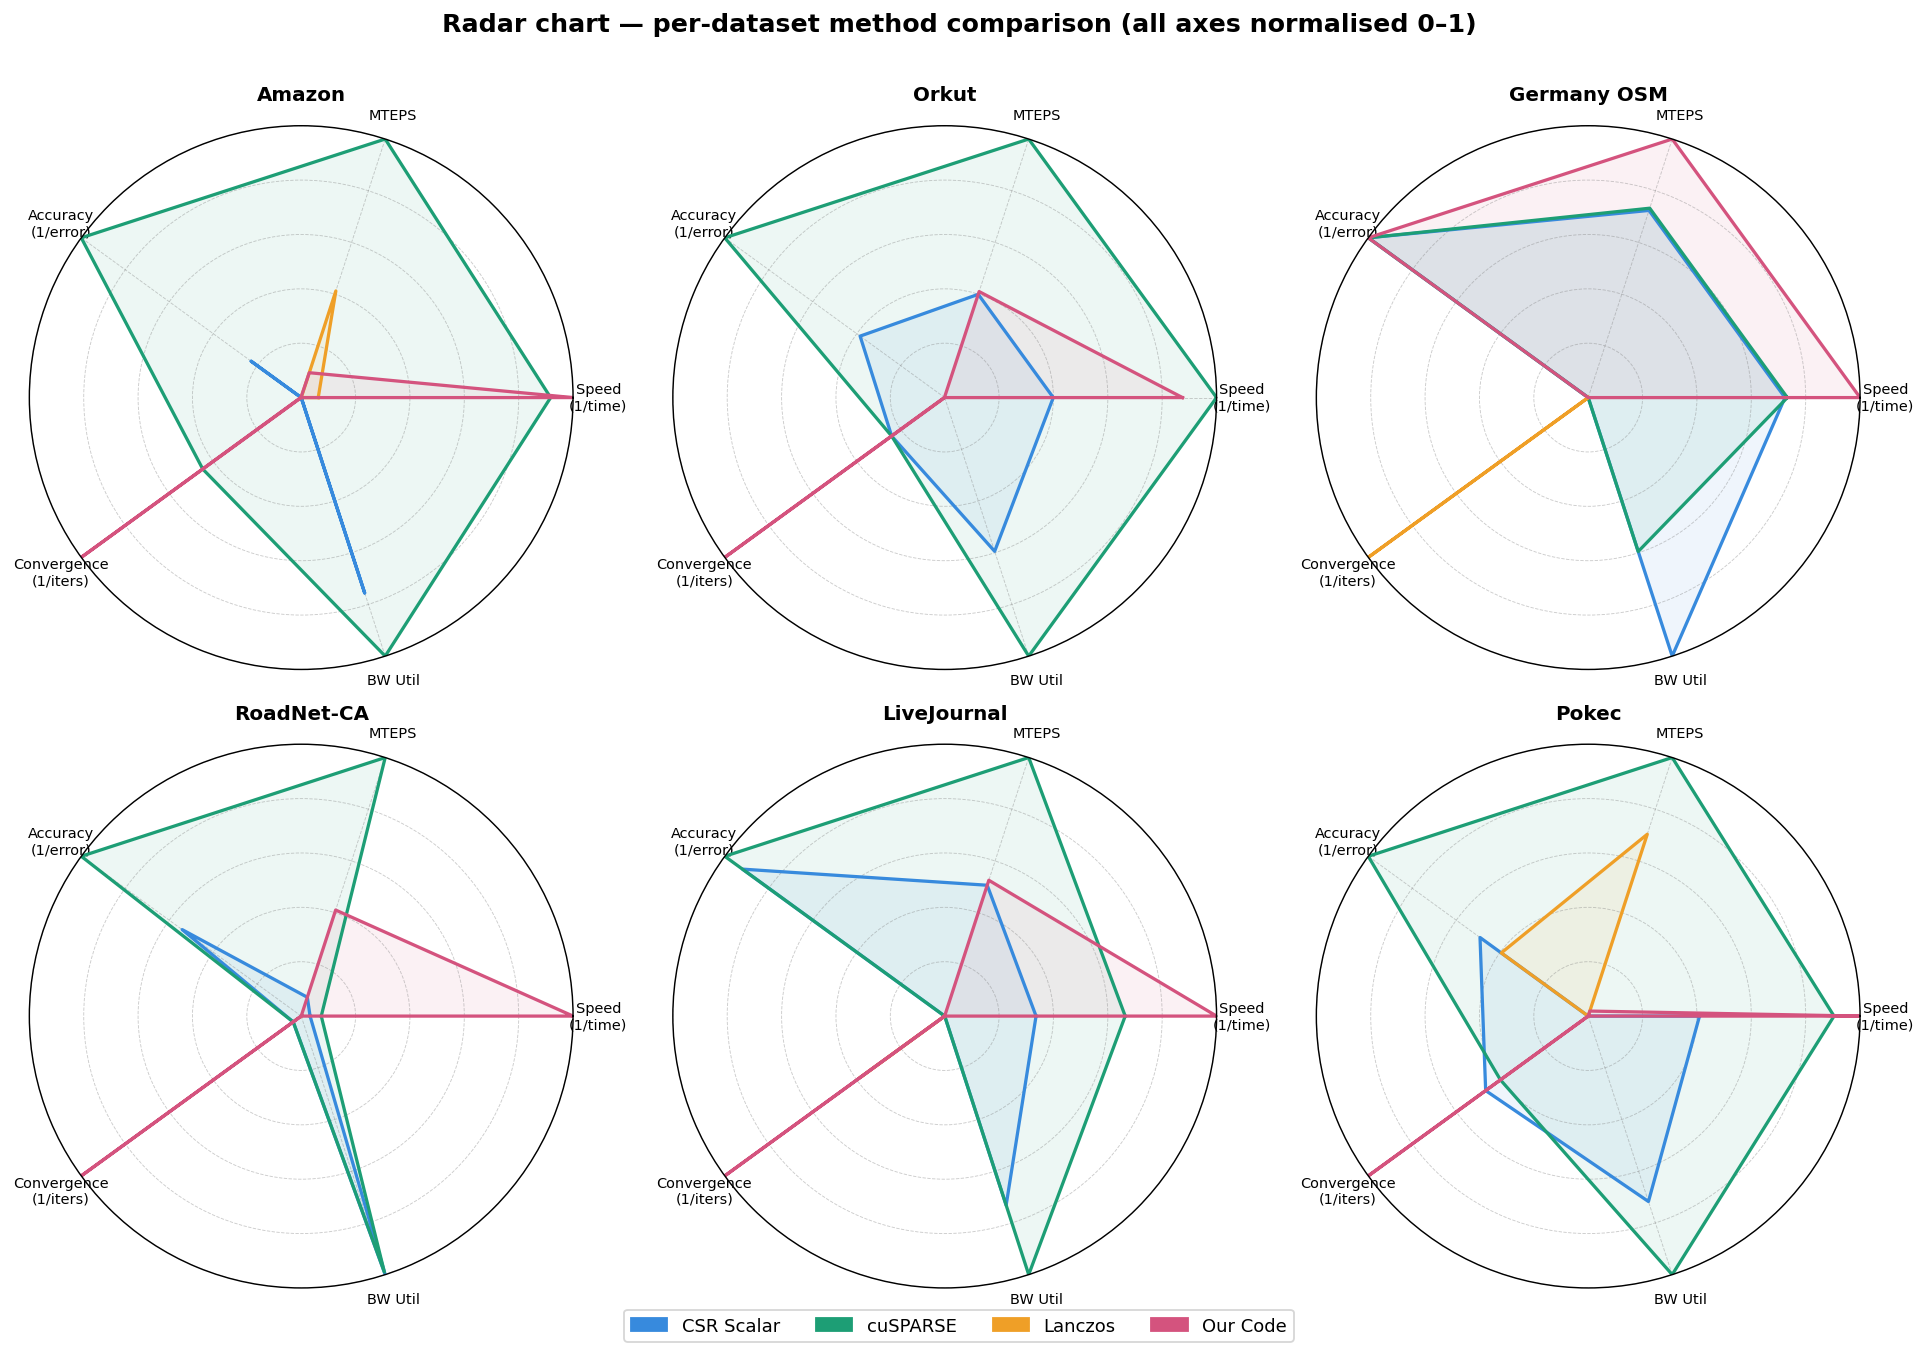

In [29]:
from matplotlib.patches import FancyArrowPatch

radar_metrics = ['exec_speed', 'mteps_norm', 'accuracy', 'convergence', 'bw_util']
radar_labels  = ['Speed\n(1/time)', 'MTEPS', 'Accuracy\n(1/error)', 'Convergence\n(1/iters)', 'BW Util']

def normalize_col(series):
    mn, mx = series.min(), series.max()
    return (series - mn) / (mx - mn + 1e-12)

num_vars = len(radar_metrics)
angles = [n / float(num_vars) * 2 * np.pi for n in range(num_vars)]
angles += angles[:1]

n_datasets = len(DATASETS)
ncols = 3
nrows = (n_datasets + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5*nrows),
                         subplot_kw=dict(polar=True))
axes_flat = axes.flatten()

for di, ds in enumerate(DATASETS):
    ax = axes_flat[di]
    for m in METHODS:
        sub = df[(df.dataset_short == ds) & (df.method_key == m)]
        if not len(sub):
            continue
        row = sub.iloc[0]
        # build radar values (0–1, higher = better)
        speed  = 1 / row.execution_time_ms if pd.notna(row.execution_time_ms) and row.execution_time_ms > 0 else 0
        mt     = row.mteps if pd.notna(row.mteps) else 0
        acc    = 1 / row.reconstruction_error_l2 if pd.notna(row.reconstruction_error_l2) and row.reconstruction_error_l2 > 0 else 0
        conv   = 1 / row.iterations if pd.notna(row.iterations) and row.iterations > 0 else 0
        bw     = row.bw_util_percent if pd.notna(row.bw_util_percent) else 0
        vals_raw = [speed, mt, acc, conv, bw]
        # per-dataset normalise
        all_vals_for_ds = []
        for m2 in METHODS:
            s2 = df[(df.dataset_short == ds) & (df.method_key == m2)]
            if len(s2):
                r2 = s2.iloc[0]
                sp2 = 1/r2.execution_time_ms if pd.notna(r2.execution_time_ms) and r2.execution_time_ms>0 else 0
                mt2 = r2.mteps if pd.notna(r2.mteps) else 0
                ac2 = 1/r2.reconstruction_error_l2 if pd.notna(r2.reconstruction_error_l2) and r2.reconstruction_error_l2>0 else 0
                co2 = 1/r2.iterations if pd.notna(r2.iterations) and r2.iterations>0 else 0
                bw2 = r2.bw_util_percent if pd.notna(r2.bw_util_percent) else 0
                all_vals_for_ds.append([sp2, mt2, ac2, co2, bw2])
        all_arr = np.array(all_vals_for_ds)
        mins = all_arr.min(axis=0)
        maxs = all_arr.max(axis=0)
        normed = [(v - mn) / (mx - mn + 1e-12) for v, mn, mx in zip(vals_raw, mins, maxs)]
        normed += normed[:1]
        ax.plot(angles, normed, color=METHOD_COLORS[m], linewidth=1.8, label=METHOD_LABELS[m])
        ax.fill(angles, normed, color=METHOD_COLORS[m], alpha=0.08)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_yticklabels([])
    ax.set_title(ds, size=11, pad=14, fontweight='bold')
    ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.4)

for ax in axes_flat[n_datasets:]:
    ax.set_visible(False)

handles = [mpatches.Patch(color=METHOD_COLORS[m], label=METHOD_LABELS[m]) for m in METHODS]
fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=10, bbox_to_anchor=(0.5, -0.02))
fig.suptitle('Radar chart — per-dataset method comparison (all axes normalised 0–1)', y=1.01)
plt.tight_layout()
plt.savefig('plot_25_radar.png', bbox_inches='tight')
plt.show()

## 26 — Parallel coordinates plot

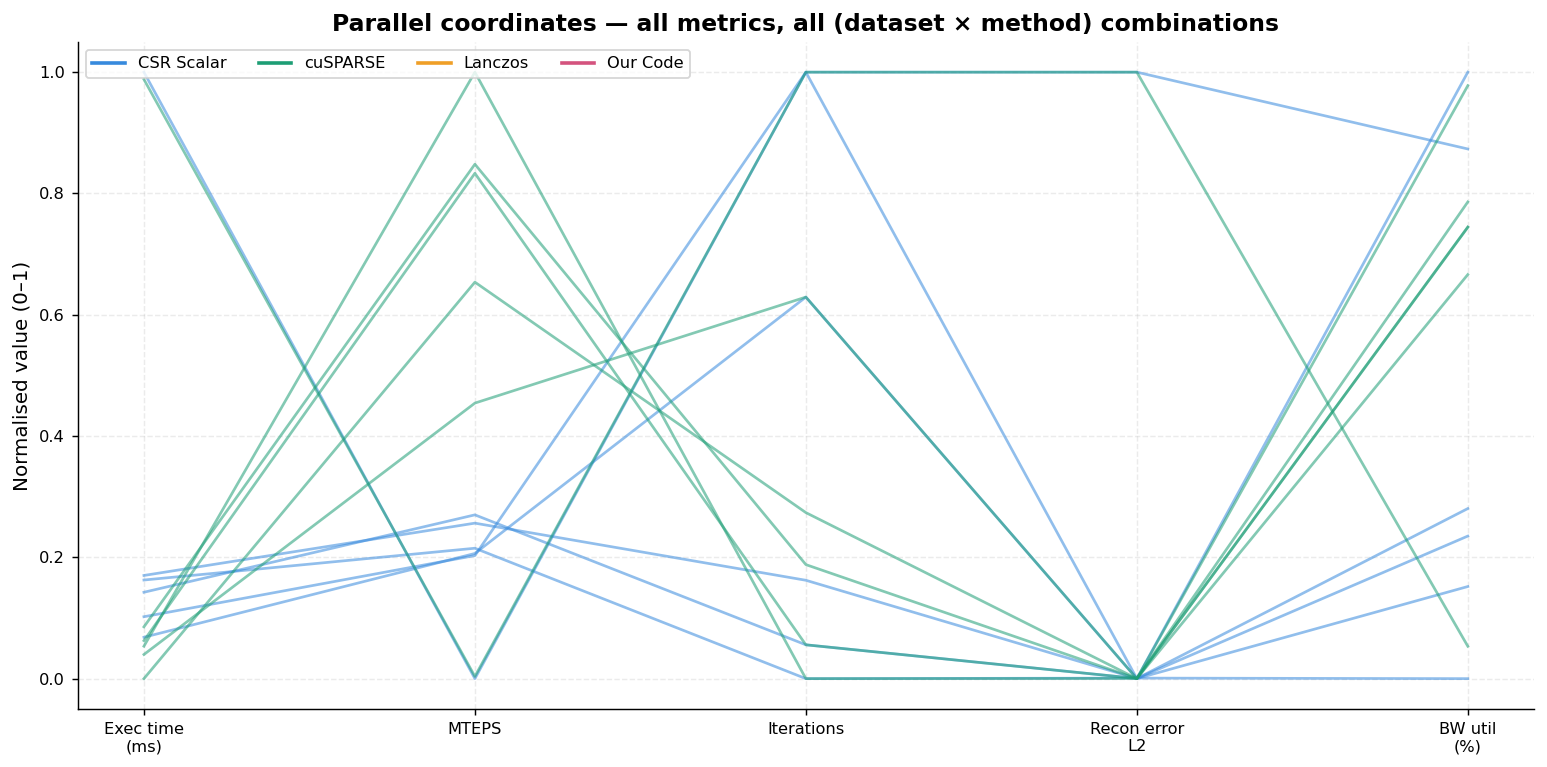

In [30]:
from pandas.plotting import parallel_coordinates

pc_cols = ['execution_time_ms', 'mteps', 'iterations', 'reconstruction_error_l2', 'bw_util_percent']
pc_labels = ['Exec time\n(ms)', 'MTEPS', 'Iterations', 'Recon error\nL2', 'BW util\n(%)']

pc_df = df[['method_label', 'dataset_short'] + pc_cols].dropna(subset=pc_cols).copy()

# min-max normalise each column
for col in pc_cols:
    mn, mx = pc_df[col].min(), pc_df[col].max()
    pc_df[col] = (pc_df[col] - mn) / (mx - mn + 1e-12)

fig, ax = plt.subplots(figsize=(12, 6))
for m in METHODS:
    sub = pc_df[pc_df.method_label == METHOD_LABELS[m]]
    for _, row in sub.iterrows():
        ax.plot(range(len(pc_cols)), row[pc_cols].values,
                color=METHOD_COLORS[m], alpha=0.55, linewidth=1.5)

ax.set_xticks(range(len(pc_cols)))
ax.set_xticklabels(pc_labels)
ax.set_ylabel('Normalised value (0–1)')
ax.set_title('Parallel coordinates — all metrics, all (dataset × method) combinations')
handles = [Line2D([0],[0], color=METHOD_COLORS[m], linewidth=2, label=METHOD_LABELS[m])
           for m in METHODS]
ax.legend(handles=handles, ncol=4)
plt.tight_layout()
plt.savefig('plot_26_parallel_coords.png', bbox_inches='tight')
plt.show()

## 27 — Scatter matrix (SPLOM)

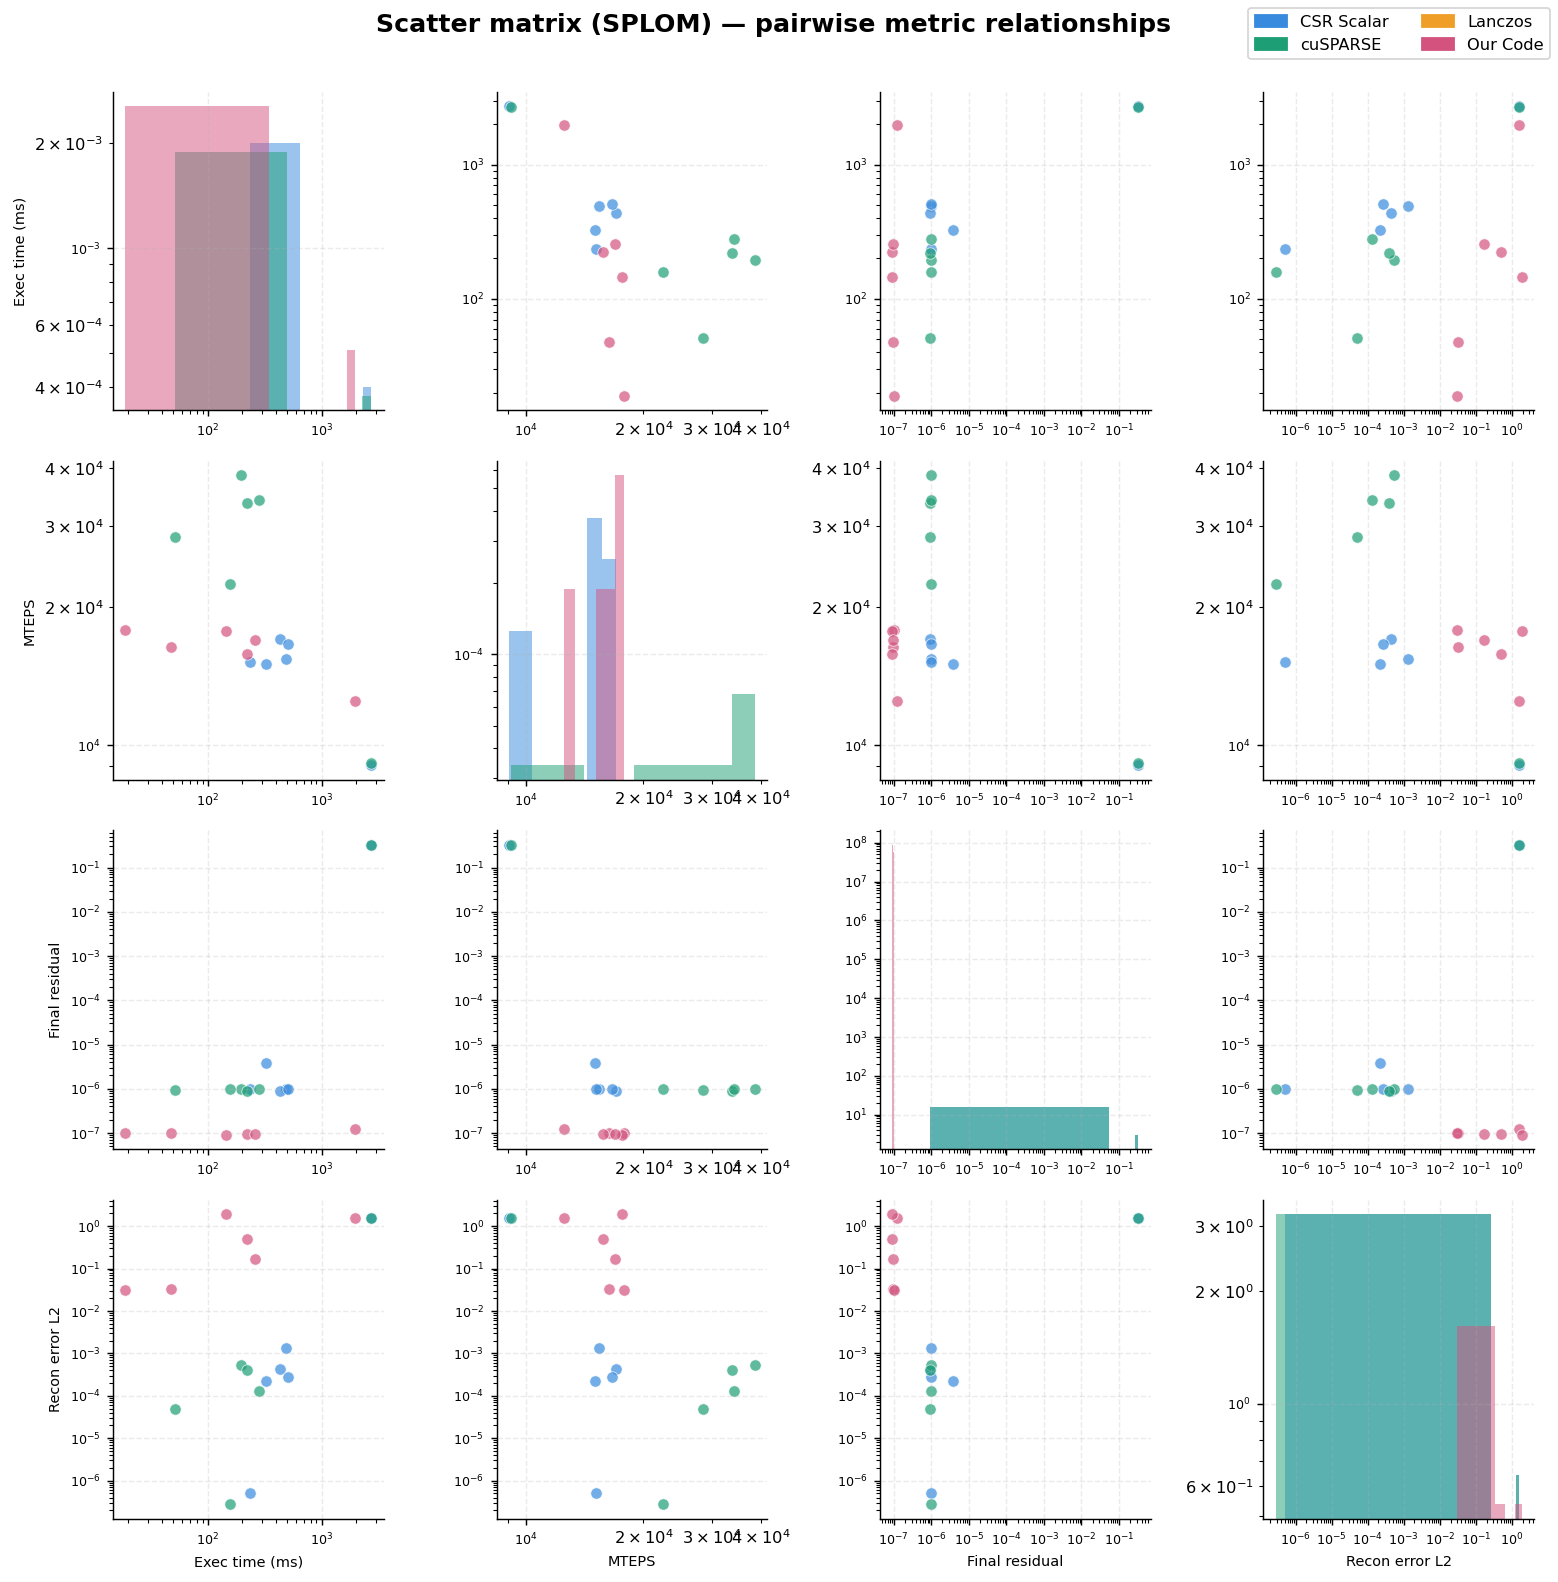

In [31]:
from pandas.plotting import scatter_matrix

splom_cols = ['execution_time_ms', 'mteps', 'final_residual', 'reconstruction_error_l2']
splom_labels = ['Exec time (ms)', 'MTEPS', 'Final residual', 'Recon error L2']
splom_df = df[['method_key'] + splom_cols].dropna(subset=splom_cols).copy()

fig, axes = plt.subplots(len(splom_cols), len(splom_cols), figsize=(12, 12))

for i, col_i in enumerate(splom_cols):
    for j, col_j in enumerate(splom_cols):
        ax = axes[i][j]
        if i == j:
            for m in METHODS:
                sub = splom_df[splom_df.method_key == m][col_i].dropna()
                if len(sub):
                    ax.hist(sub, alpha=0.5, color=METHOD_COLORS[m], bins=6, density=True)
        else:
            for m in METHODS:
                sub = splom_df[splom_df.method_key == m]
                ax.scatter(sub[col_j], sub[col_i],
                           color=METHOD_COLORS[m], s=40, alpha=0.7,
                           edgecolors='white', linewidth=0.5)
        if i == len(splom_cols)-1:
            ax.set_xlabel(splom_labels[j], fontsize=8)
        if j == 0:
            ax.set_ylabel(splom_labels[i], fontsize=8)
        ax.tick_params(labelsize=7)
        try:
            ax.set_xscale('log')
            ax.set_yscale('log')
        except Exception:
            pass
        for spine in ['top','right']:
            ax.spines[spine].set_visible(False)

handles = [mpatches.Patch(color=METHOD_COLORS[m], label=METHOD_LABELS[m]) for m in METHODS]
fig.legend(handles=handles, loc='upper right', ncol=2, fontsize=9)
fig.suptitle('Scatter matrix (SPLOM) — pairwise metric relationships', y=1.01)
plt.tight_layout()
plt.savefig('plot_27_splom.png', bbox_inches='tight')
plt.show()

## 28 — Phase share donut charts per method

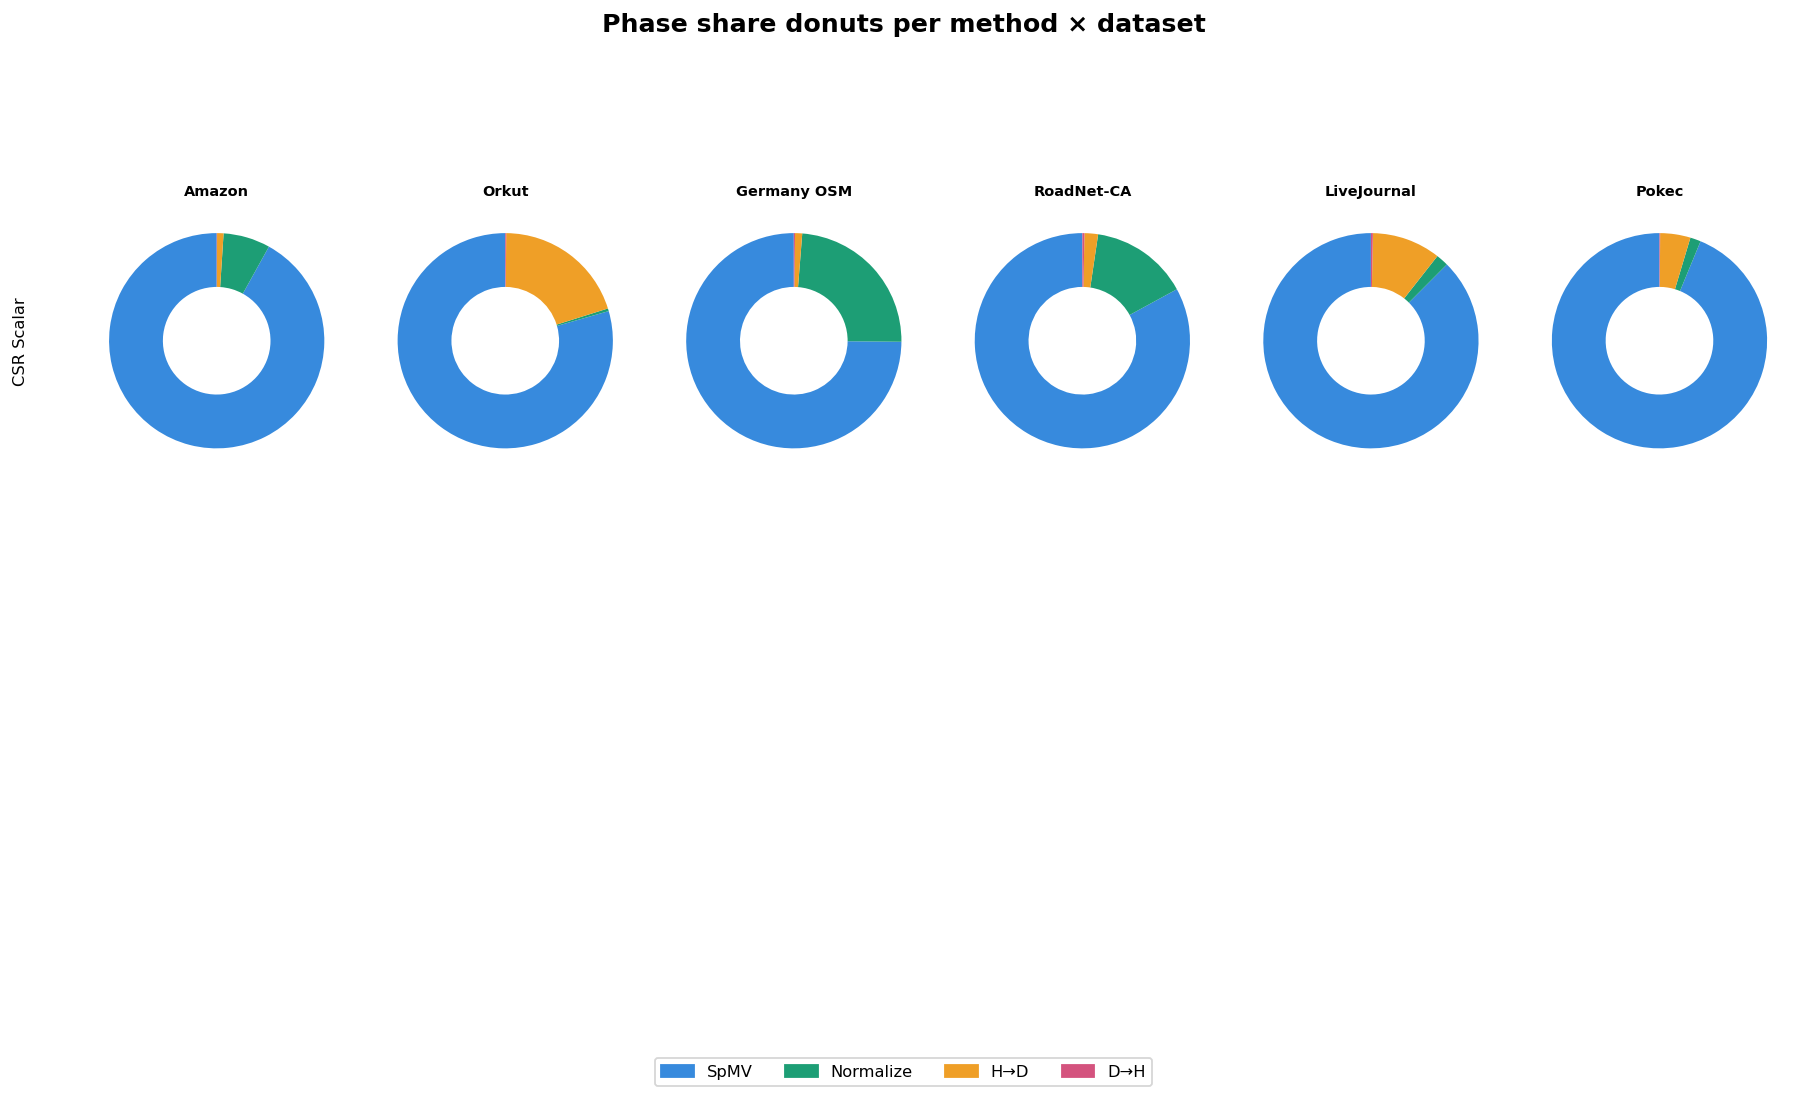

In [32]:
phases = ['spmv_ms', 'normalize_ms', 'h2d_ms', 'd2h_ms']
phase_labels = ['SpMV', 'Normalize', 'H→D', 'D→H']
phase_clrs = ['#378ADD', '#1D9E75', '#EF9F27', '#D4537E']

donut_methods = ['csr_scalar', 'our_code']
fig, axes = plt.subplots(len(donut_methods), len(DATASETS),
                         figsize=(14, 4 * len(donut_methods)))

for ri, m in enumerate(donut_methods):
    for ci, ds in enumerate(DATASETS):
        ax = axes[ri][ci]
        sub = df[(df.dataset_short == ds) & (df.method_key == m)]
        if not len(sub):
            ax.set_visible(False)
            continue
        vals = [sub[ph].values[0] if pd.notna(sub[ph].values[0]) else 0 for ph in phases]
        total = sum(vals)
        if total == 0:
            ax.set_visible(False)
            continue
        wedges, _ = ax.pie(vals, colors=phase_clrs,
                           startangle=90, wedgeprops=dict(width=0.5))
        ax.set_title(ds, fontsize=8)
        if ci == 0:
            ax.set_ylabel(METHOD_LABELS[m], fontsize=9, labelpad=30)

legend_handles = [mpatches.Patch(color=c, label=l) for c, l in zip(phase_clrs, phase_labels)]
fig.legend(handles=legend_handles, loc='lower center', ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.03))
fig.suptitle('Phase share donuts per method × dataset', y=1.01)
plt.tight_layout()
plt.savefig('plot_28_phase_donuts.png', bbox_inches='tight')
plt.show()

---
## Summary of saved plots
| # | File | What it shows |
|---|------|---------------|
| 1 | `plot_01_exec_time_grouped_bar.png` | Execution time by method & dataset |
| 2 | `plot_02_speedup_bar.png` | Relative speedup vs. csr_scalar |
| 3 | `plot_03_mteps_line.png` | MTEPS across datasets |
| 4 | `plot_04_mteps_vs_edges_scatter.png` | MTEPS vs. graph size |
| 5 | `plot_05_speedup_heatmap.png` | Speedup heatmap |
| 6 | `plot_06_iterations_bar.png` | Iterations to converge |
| 7 | `plot_07_convergence_heatmap.png` | Convergence status heatmap |
| 8 | `plot_08_residual_vs_iters.png` | Residual vs. iterations |
| 9 | `plot_09_residual_vs_time.png` | Convergence Pareto |
| 10 | `plot_10_recon_error_bar.png` | Reconstruction error (log bar) |
| 11 | `plot_11_recon_error_heatmap.png` | Reconstruction error heatmap |
| 12 | `plot_12_accuracy_pareto.png` | Accuracy Pareto frontier |
| 13 | `plot_13_top_score_bar.png` | Top eigenscore comparison |
| 14 | `plot_14_bw_util_stacked.png` | Bandwidth utilisation |
| 15 | `plot_15_bw_vs_mteps.png` | BW util vs. MTEPS |
| 16 | `plot_16_gflops_line.png` | Effective GFLOPS |
| 17 | `plot_17_memory_bar.png` | GPU memory footprint |
| 18 | `plot_18_phase_breakdown.png` | Runtime phase breakdown |
| 19 | `plot_19_avg_iter_ms.png` | Avg per-iteration time |
| 20 | `plot_20_spmv_vs_nnz.png` | SpMV time vs. NNZ |
| 21 | `plot_21_exec_vs_density.png` | Exec time vs. graph density |
| 22 | `plot_22_scaling.png` | Scaling: exec time vs. num_edges |
| 23 | `plot_23_bubble.png` | Bubble: iterations × residual × time |
| 24 | `plot_24_composite_score.png` | Composite efficiency score |
| 25 | `plot_25_radar.png` | Radar chart per dataset |
| 26 | `plot_26_parallel_coords.png` | Parallel coordinates |
| 27 | `plot_27_splom.png` | Scatter matrix (SPLOM) |
| 28 | `plot_28_phase_donuts.png` | Phase share donuts |